In [2]:
!pip install numpy==1.26.4



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 0 – Environment Setup
This step prepares the Python environment by importing all required libraries for data manipulation and visualizatio

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Feature Engineering and Business Metrics Layer

After completing the data quality preparation phase, the next step is to create a business-ready metrics layer.

This layer transforms raw fields into analytical features that support EDA, dashboarding, and advanced business analysis.

### Purpose

The purpose of this step is to create consistent and reusable metrics for answering the business questions related to:

- revenue and order trends,
- product and category performance,
- delivery performance,
- customer loyalty and repeat behavior,
- RFM segmentation,
- cohort retention,
- basket analysis,
- customer value concentration.

### Key Principle

All features must be created at the correct analytical grain to avoid double counting.

Examples:

- Order-level metrics should be calculated at `order_id` level.
- Item/category metrics should be calculated at `order_id + order_item_id` level.
- Customer metrics should be calculated at `customer_unique_id` level.
- Geolocation joins should use `ref_geolocation_zip`, not the raw geolocation table.

## Step 1 – Data Loading

#The datasets are loaded from locally uploaded CSV files within the Jupyter environment.
#These files represent structured extracts of the original SQL database.

#Primary keys and foreign keys were enforced at the database level prior to extraction.
#Therefore, the datasets are expected to be relationally consistent and ready for analysis.

In [4]:
import pandas as pd

# Load cleaned datasets from exported CSV files.
# Date columns are parsed directly while loading to support time-based feature engineering.

core_customers = pd.read_csv("core_customers_clean.csv")

core_orders = pd.read_csv(
    "core_orders_clean.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

core_order_items = pd.read_csv("core_order_items_clean.csv")
core_payments = pd.read_csv("core_payments_clean.csv")
core_products = pd.read_csv("core_products_clean.csv")

core_reviews = pd.read_csv(
    "core_reviews_clean.csv",
    parse_dates=[
        "review_creation_date",
        "review_answer_timestamp"
    ]
)

core_sellers = pd.read_csv("core_sellers_clean.csv")
ref_category_translation = pd.read_csv("ref_category_translation_clean.csv")
ref_geolocation_zip = pd.read_csv("ref_geolocation_zip.csv")

print("✅ Clean datasets loaded successfully")

✅ Clean datasets loaded successfully


In [5]:
# Create item-level financial features.
# This keeps the data at order-item grain.

order_items_features = core_order_items.copy()

# Calculate total item value including product price and freight value.
order_items_features["item_total_value"] = (
    order_items_features["price"] + order_items_features["freight_value"]
)

print("✅ Item-level financial feature created")
display(order_items_features.head())

✅ Item-level financial feature created


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,dq_price_non_positive,dq_freight_negative,item_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,1970-01-01 00:00:00.000042997,58.90,13.29,False,False,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,1970-01-01 00:00:00.000042858,239.90,19.93,False,False,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1970-01-01 00:00:00.000043118,199.00,17.87,False,False,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,1970-01-01 00:00:00.000043327,12.99,12.79,False,False,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,1970-01-01 00:00:00.000042779,199.90,18.14,False,False,218.04


In [6]:
# Aggregate item-level metrics to order level.
# This creates one row per order_id.

order_items_order_level = (
    order_items_features
    .groupby("order_id", as_index=False)
    .agg(
        order_items_total_price=("price", "sum"),
        order_items_total_freight=("freight_value", "sum"),
        order_items_total_value=("item_total_value", "sum"),
        basket_size=("order_item_id", "count"),
        unique_products_count=("product_id", "nunique"),
        unique_sellers_count=("seller_id", "nunique")
    )
)

print("✅ Order item metrics aggregated to order level")
display(order_items_order_level.head())

✅ Order item metrics aggregated to order level


,order_id,order_items_total_price,order_items_total_freight,order_items_total_value,basket_size,unique_products_count,unique_sellers_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04,1,1,1


In [7]:
# Aggregate payment metrics to order level.
# This avoids double counting when an order has multiple payment rows.

payments_order_level = (
    core_payments
    .groupby("order_id", as_index=False)
    .agg(
        payment_revenue=("payment_value", "sum"),
        payment_rows_count=("payment_sequential", "count"),
        max_payment_installments=("payment_installments", "max"),
        payment_types_count=("payment_type", "nunique")
    )
)

print("✅ Payment metrics aggregated to order level")
display(payments_order_level.head())

✅ Payment metrics aggregated to order level


,order_id,payment_revenue,payment_rows_count,max_payment_installments,payment_types_count
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3,1
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3,1


In [8]:
# Build the main order-level feature table.
# The output should have one row per order_id.

customer_cols = [
    "customer_id",
    "customer_unique_id",
    "customer_city",
    "customer_state"
]

# Add geolocation match flag if it exists in the cleaned customer table.
if "has_geolocation_match" in core_customers.columns:
    customer_cols.append("has_geolocation_match")

orders_features = (
    core_orders
    .merge(order_items_order_level, on="order_id", how="left")
    .merge(payments_order_level, on="order_id", how="left")
    .merge(core_customers[customer_cols], on="customer_id", how="left")
)

# Validate order-level grain.
print("Rows in orders_features:", len(orders_features))
print("Unique order_id:", orders_features["order_id"].nunique())

if len(orders_features) == orders_features["order_id"].nunique():
    print("✅ orders_features has one row per order_id")
else:
    print("⚠️ Grain issue: duplicated order_id found")

display(orders_features.head())

Rows in orders_features: 99441
Unique order_id: 99441
✅ orders_features has one row per order_id


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dq_delivered_missing_approved_at,dq_delivered_missing_carrier_date,...,unique_products_count,unique_sellers_count,payment_revenue,payment_rows_count,max_payment_installments,payment_types_count,customer_unique_id,customer_city,customer_state,has_geolocation_match
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13,2017-09-13,2017-09-19,2017-09-20,2017-09-29,False,False,...,1.0,1.0,72.19,1.0,2.0,1.0,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,True
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-04-26,2017-05-04,2017-05-12,2017-05-15,False,False,...,1.0,1.0,259.83,1.0,3.0,1.0,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,True
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-14,2018-01-16,2018-01-22,2018-02-05,False,False,...,1.0,1.0,216.87,1.0,5.0,1.0,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,True
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-08,2018-08-10,2018-08-14,2018-08-20,False,False,...,1.0,1.0,25.78,1.0,2.0,1.0,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-02-04,2017-02-16,2017-03-01,2017-03-17,False,False,...,1.0,1.0,218.04,1.0,3.0,1.0,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,True


In [9]:
# Create time-based features from order_purchase_timestamp.
# These features support trend, seasonality, and time-based analysis.

orders_features["purchase_date"] = orders_features["order_purchase_timestamp"].dt.date
orders_features["purchase_year"] = orders_features["order_purchase_timestamp"].dt.year
orders_features["purchase_month"] = orders_features["order_purchase_timestamp"].dt.month
orders_features["purchase_quarter"] = orders_features["order_purchase_timestamp"].dt.quarter
orders_features["purchase_weekday"] = orders_features["order_purchase_timestamp"].dt.day_name()
orders_features["purchase_year_month"] = (
    orders_features["order_purchase_timestamp"].dt.to_period("M").astype(str)
)

print("✅ Time-based features created")
display(
    orders_features[
        [
            "order_id",
            "order_purchase_timestamp",
            "purchase_year",
            "purchase_month",
            "purchase_quarter",
            "purchase_weekday",
            "purchase_year_month"
        ]
    ].head()
)

✅ Time-based features created


,order_id,order_purchase_timestamp,purchase_year,purchase_month,purchase_quarter,purchase_weekday,purchase_year_month
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13,2017,9,3,Wednesday,2017-09
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26,2017,4,2,Wednesday,2017-04
2,000229ec398224ef6ca0657da4fc703e,2018-01-14,2018,1,1,Sunday,2018-01
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08,2018,8,3,Wednesday,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04,2017,2,1,Saturday,2017-02


In [10]:
# Create revenue base fields.
# Payment-based revenue and item-based revenue are kept separately for correct KPI usage.

orders_features["payment_revenue"] = orders_features["payment_revenue"]
orders_features["item_based_revenue"] = orders_features["order_items_total_value"]

# Difference between payment-based and item-based revenue.
orders_features["payment_vs_item_revenue_diff"] = (
    orders_features["payment_revenue"] - orders_features["item_based_revenue"]
)

print("✅ Revenue base features created")
display(
    orders_features[
        [
            "order_id",
            "payment_revenue",
            "item_based_revenue",
            "payment_vs_item_revenue_diff"
        ]
    ].head()
)

✅ Revenue base features created


,order_id,payment_revenue,item_based_revenue,payment_vs_item_revenue_diff
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,72.19,0.000000e+00
1,00018f77f2f0320c557190d7a144bdd3,259.83,259.83,0.000000e+00
2,000229ec398224ef6ca0657da4fc703e,216.87,216.87,0.000000e+00
3,00024acbcdf0a6daa1e931b038114c75,25.78,25.78,0.000000e+00
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,218.04,-2.842171e-14


In [11]:
# Create delivery performance features.
# These features support delivery and logistics analysis.

orders_features["delivery_days"] = (
    orders_features["order_delivered_customer_date"] -
    orders_features["order_purchase_timestamp"]
).dt.days

orders_features["estimated_delivery_days"] = (
    orders_features["order_estimated_delivery_date"] -
    orders_features["order_purchase_timestamp"]
).dt.days

orders_features["delivery_delay_days"] = (
    orders_features["order_delivered_customer_date"] -
    orders_features["order_estimated_delivery_date"]
).dt.days

orders_features["is_late_delivery"] = (
    orders_features["order_delivered_customer_date"].notna() &
    orders_features["order_estimated_delivery_date"].notna() &
    (orders_features["order_delivered_customer_date"] > orders_features["order_estimated_delivery_date"])
)

print("✅ Delivery features created")
display(
    orders_features[
        [
            "order_id",
            "order_status",
            "delivery_days",
            "estimated_delivery_days",
            "delivery_delay_days",
            "is_late_delivery"
        ]
    ].head()
)

✅ Delivery features created


,order_id,order_status,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,delivered,7.0,16,-9.0,False
1,00018f77f2f0320c557190d7a144bdd3,delivered,16.0,19,-3.0,False
2,000229ec398224ef6ca0657da4fc703e,delivered,8.0,22,-14.0,False
3,00024acbcdf0a6daa1e931b038114c75,delivered,6.0,12,-6.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,delivered,25.0,41,-16.0,False


In [12]:
# Create enriched item-level table with product and category information.
# This table supports product/category analysis and basket analysis.

product_cols = [
    "product_id",
    "product_category_name",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

order_items_category_features = (
    order_items_features
    .merge(core_products[product_cols], on="product_id", how="left")
    .merge(ref_category_translation, on="product_category_name", how="left")
)

print("✅ Product and category feature table created")
print("Rows:", len(order_items_category_features))
display(order_items_category_features.head())

✅ Product and category feature table created
Rows: 112650


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,dq_price_non_positive,dq_freight_negative,item_total_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,1970-01-01 00:00:00.000042997,58.90,13.29,False,False,72.19,cool_stuff,650,28,9,14,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,1970-01-01 00:00:00.000042858,239.90,19.93,False,False,259.83,pet_shop,30000,50,30,40,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,1970-01-01 00:00:00.000043118,199.00,17.87,False,False,216.87,moveis_decoracao,3050,33,13,33,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,1970-01-01 00:00:00.000043327,12.99,12.79,False,False,25.78,perfumaria,200,16,10,15,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,1970-01-01 00:00:00.000042779,199.90,18.14,False,False,218.04,ferramentas_jardim,3750,35,40,30,garden_tools


In [13]:
# Create customer-level features using customer_unique_id.
# This supports repeat customer analysis, customer value, and RFM preparation.

customer_features = (
    orders_features
    .groupby("customer_unique_id", as_index=False)
    .agg(
        first_purchase_date=("order_purchase_timestamp", "min"),
        last_purchase_date=("order_purchase_timestamp", "max"),
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_revenue", "sum"),
        average_order_value=("payment_revenue", "mean"),
        customer_state=("customer_state", "first"),
        customer_city=("customer_city", "first")
    )
)

customer_features["is_repeat_customer"] = customer_features["total_orders"] > 1

customer_features["customer_tenure_days"] = (
    customer_features["last_purchase_date"] -
    customer_features["first_purchase_date"]
).dt.days

print("✅ Customer-level features created")
display(customer_features.head())

✅ Customer-level features created


,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,customer_state,customer_city,is_repeat_customer,customer_tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,2018-05-10,1,141.90,141.90,SP,cajamar,False,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,2018-05-07,1,27.19,27.19,SP,osasco,False,0
2,0000f46a3911fa3c0805444483337064,2017-03-10,2017-03-10,1,86.22,86.22,SC,sao jose,False,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,2017-10-12,1,43.62,43.62,PA,belem,False,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,2017-11-14,1,196.89,196.89,SP,sorocaba,False,0


In [14]:
# Create cohort month based on each customer's first purchase month.
# This is the base feature for cohort retention analysis.

customer_features["cohort_month"] = (
    customer_features["first_purchase_date"].dt.to_period("M").astype(str)
)

# Add cohort and repeat customer flag back to the order-level table.
orders_features = orders_features.merge(
    customer_features[
        [
            "customer_unique_id",
            "cohort_month",
            "is_repeat_customer"
        ]
    ],
    on="customer_unique_id",
    how="left"
)

print("✅ Cohort month and repeat customer flag added to orders_features")
display(
    orders_features[
        [
            "order_id",
            "customer_unique_id",
            "purchase_year_month",
            "cohort_month",
            "is_repeat_customer"
        ]
    ].head()
)

✅ Cohort month and repeat customer flag added to orders_features


,order_id,customer_unique_id,purchase_year_month,cohort_month,is_repeat_customer
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,2017-09,2017-09,False
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,2017-04,2017-04,True
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,2018-01,2018-01,False
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,2018-08,2018-08,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,2017-02,2017-02,False


In [15]:
# Create RFM base table.
# Recency is calculated relative to one day after the latest purchase date.

analysis_date = orders_features["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm_base = (
    orders_features
    .groupby("customer_unique_id", as_index=False)
    .agg(
        last_purchase_date=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("payment_revenue", "sum")
    )
)

rfm_base["recency"] = (
    analysis_date - rfm_base["last_purchase_date"]
).dt.days

print("✅ RFM base table created")
print("Analysis date:", analysis_date)
display(rfm_base.head())

✅ RFM base table created
Analysis date: 2018-10-18 00:00:00


,customer_unique_id,last_purchase_date,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,1,141.90,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,1,27.19,164
2,0000f46a3911fa3c0805444483337064,2017-03-10,1,86.22,587
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,1,43.62,371
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,1,196.89,338


In [16]:
# Create RFM scores and customer segments.
# Scores range from 1 to 5, where 5 represents the best customer behavior.

rfm_scored = rfm_base.copy()

# Recency scoring:
# Lower recency is better, so the most recent customers receive higher scores.
rfm_scored["recency_score"] = pd.qcut(
    rfm_scored["recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency scoring:
# Higher frequency is better, so customers with more orders receive higher scores.
rfm_scored["frequency_score"] = pd.qcut(
    rfm_scored["frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary scoring:
# Higher monetary value is better, so customers with higher spending receive higher scores.
rfm_scored["monetary_score"] = pd.qcut(
    rfm_scored["monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combine the three scores into one RFM score string.
rfm_scored["rfm_score"] = (
    rfm_scored["recency_score"].astype(str) +
    rfm_scored["frequency_score"].astype(str) +
    rfm_scored["monetary_score"].astype(str)
)

# Create a total RFM score for ranking customers.
rfm_scored["rfm_total_score"] = (
    rfm_scored["recency_score"] +
    rfm_scored["frequency_score"] +
    rfm_scored["monetary_score"]
)

# Define customer segment logic based on RFM scores.
def assign_rfm_segment(row):
    r = row["recency_score"]
    f = row["frequency_score"]
    m = row["monetary_score"]
    
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 4:
        return "Loyal Customers"
    elif r >= 4 and f >= 2:
        return "Potential Loyalists"
    elif r == 5 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2:
        return "Hibernating"
    else:
        return "Others"

# Apply segmentation logic.
rfm_scored["rfm_segment"] = rfm_scored.apply(assign_rfm_segment, axis=1)

print("✅ RFM scores and customer segments created")
display(rfm_scored.head())

✅ RFM scores and customer segments created


,customer_unique_id,last_purchase_date,frequency,monetary,recency,recency_score,frequency_score,monetary_score,rfm_score,rfm_total_score,rfm_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,1,141.90,161,4,1,4,414,9,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,1,27.19,164,4,1,1,411,6,Others
2,0000f46a3911fa3c0805444483337064,2017-03-10,1,86.22,587,1,1,2,112,4,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,1,43.62,371,2,1,1,211,4,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,1,196.89,338,2,1,4,214,7,Hibernating


In [17]:
# Summarize customer segments.
# This gives a high-level view of customer distribution and value by segment.

rfm_segment_summary = (
    rfm_scored
    .groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count"),
        total_revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_rfm_total_score=("rfm_total_score", "mean")
    )
)

# Calculate customer and revenue percentages.
rfm_segment_summary["customer_percentage"] = (
    rfm_segment_summary["customer_count"] / rfm_segment_summary["customer_count"].sum() * 100
).round(2)

rfm_segment_summary["revenue_percentage"] = (
    rfm_segment_summary["total_revenue"] / rfm_segment_summary["total_revenue"].sum() * 100
).round(2)

# Round numeric columns for cleaner display.
rfm_segment_summary["total_revenue"] = rfm_segment_summary["total_revenue"].round(2)
rfm_segment_summary["avg_recency"] = rfm_segment_summary["avg_recency"].round(2)
rfm_segment_summary["avg_frequency"] = rfm_segment_summary["avg_frequency"].round(2)
rfm_segment_summary["avg_monetary"] = rfm_segment_summary["avg_monetary"].round(2)
rfm_segment_summary["avg_rfm_total_score"] = rfm_segment_summary["avg_rfm_total_score"].round(2)

# Sort by revenue contribution.
rfm_segment_summary = rfm_segment_summary.sort_values(
    "total_revenue",
    ascending=False
)

print("✅ RFM segment summary created")
display(rfm_segment_summary)

✅ RFM segment summary created


,rfm_segment,customer_count,total_revenue,avg_recency,avg_frequency,avg_monetary,avg_rfm_total_score,customer_percentage,revenue_percentage
0,At Risk,23012,3880999.99,445.87,1.05,168.65,8.49,23.95,24.24
6,Potential Loyalists,15404,2550606.28,140.99,1.00,165.58,9.98,16.03,15.93
2,Hibernating,15426,2532878.43,447.42,1.00,164.20,5.95,16.05,15.82
5,Others,15312,2392809.80,250.00,1.00,156.27,7.95,15.93,14.95
1,Champions,6668,2118493.52,140.83,1.19,317.71,13.57,6.94,13.23
3,Loyal Customers,16445,1912182.42,201.52,1.06,116.28,10.78,17.11,11.94
4,New Customers,3829,620901.68,95.84,1.00,162.16,9.02,3.98,3.88


In [18]:
# Add RFM scores and segment labels back to the customer feature table.
# This creates a customer-level feature table ready for customer analysis.

customer_features = customer_features.merge(
    rfm_scored[
        [
            "customer_unique_id",
            "recency",
            "frequency",
            "monetary",
            "recency_score",
            "frequency_score",
            "monetary_score",
            "rfm_score",
            "rfm_total_score",
            "rfm_segment"
        ]
    ],
    on="customer_unique_id",
    how="left"
)

print("✅ RFM features added to customer_features")
display(customer_features.head())

✅ RFM features added to customer_features


,customer_unique_id,first_purchase_date,last_purchase_date,total_orders,total_revenue,average_order_value,customer_state,customer_city,is_repeat_customer,customer_tenure_days,cohort_month,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,rfm_total_score,rfm_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10,2018-05-10,1,141.90,141.90,SP,cajamar,False,0,2018-05,161,1,141.90,4,1,4,414,9,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07,2018-05-07,1,27.19,27.19,SP,osasco,False,0,2018-05,164,1,27.19,4,1,1,411,6,Others
2,0000f46a3911fa3c0805444483337064,2017-03-10,2017-03-10,1,86.22,86.22,SC,sao jose,False,0,2017-03,587,1,86.22,1,1,2,112,4,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12,2017-10-12,1,43.62,43.62,PA,belem,False,0,2017-10,371,1,43.62,2,1,1,211,4,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14,2017-11-14,1,196.89,196.89,SP,sorocaba,False,0,2017-11,338,1,196.89,2,1,4,214,7,Hibernating


In [19]:
# Validate RFM feature output.
# This ensures all customers received RFM scores and segments.

rfm_validation = pd.DataFrame({
    "check": [
        "Rows in customer_features",
        "Unique customers in customer_features",
        "Missing RFM segments",
        "Missing RFM scores"
    ],
    "value": [
        len(customer_features),
        customer_features["customer_unique_id"].nunique(),
        customer_features["rfm_segment"].isna().sum(),
        customer_features["rfm_score"].isna().sum()
    ]
})

display(rfm_validation)

,check,value
0,Rows in customer_features,96096
1,Unique customers in customer_features,96096
2,Missing RFM segments,0
3,Missing RFM scores,0


## RFM Scoring and Segmentation

RFM scoring was created as part of the Feature Engineering and Business Metrics Layer.

### RFM Components

- Recency: number of days since the customer's last purchase.
- Frequency: number of distinct orders placed by the customer.
- Monetary: total revenue generated by the customer.

Each component was converted into a score from 1 to 5, where 5 represents stronger customer behavior.

### Customer Segments Created

Customers were assigned to business-friendly segments such as:

- Champions
- Loyal Customers
- Potential Loyalists
- New Customers
- At Risk
- Hibernating
- Others

### Decision

RFM scoring was created during Feature Engineering because it will be used as an input for EDA, customer segmentation, revenue contribution analysis, and dashboard reporting.

Detailed interpretation of each customer segment will be handled later during the Analytical Methods / EDA phase.

In [20]:
# Create basket-level features at order level.
# This supports basket size and category combination analysis.

basket_features = (
    order_items_category_features
    .groupby("order_id", as_index=False)
    .agg(
        basket_size=("order_item_id", "count"),
        unique_products=("product_id", "nunique"),
        unique_categories=("product_category_name_english", "nunique"),
        categories_in_order=(
            "product_category_name_english",
            lambda x: list(sorted(set(x.dropna())))
        )
    )
)

print("✅ Basket-level features created")
display(basket_features.head())

✅ Basket-level features created


,order_id,basket_size,unique_products,unique_categories,categories_in_order
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,[cool_stuff]
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,[pet_shop]
2,000229ec398224ef6ca0657da4fc703e,1,1,1,[furniture_decor]
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,[perfumery]
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,[garden_tools]


In [21]:
# Validate the analytical grain of each feature table.
# This ensures feature engineering did not create unintended row duplication.

feature_table_validation = pd.DataFrame({
    "feature_table": [
        "orders_features",
        "order_items_category_features",
        "customer_features",
        "rfm_base",
        "basket_features"
    ],
    "rows": [
        len(orders_features),
        len(order_items_category_features),
        len(customer_features),
        len(rfm_base),
        len(basket_features)
    ],
    "expected_grain": [
        "one row per order_id",
        "one row per order item",
        "one row per customer_unique_id",
        "one row per customer_unique_id",
        "one row per order_id"
    ],
    "unique_grain_count": [
        orders_features["order_id"].nunique(),
        len(order_items_category_features),
        customer_features["customer_unique_id"].nunique(),
        rfm_base["customer_unique_id"].nunique(),
        basket_features["order_id"].nunique()
    ]
})

feature_table_validation["grain_is_valid"] = (
    feature_table_validation["rows"] ==
    feature_table_validation["unique_grain_count"]
)

display(feature_table_validation)

,feature_table,rows,expected_grain,unique_grain_count,grain_is_valid
0,orders_features,99441,one row per order_id,99441,True
1,order_items_category_features,112650,one row per order item,112650,True
2,customer_features,96096,one row per customer_unique_id,96096,True
3,rfm_base,96096,one row per customer_unique_id,96096,True
4,basket_features,98666,one row per order_id,98666,True


## Feature Table Grain Validation Summary

Feature tableIs, incorrect revenue calculations, and misleading dashboard results.Feature table grain validation was performed to confirm that each engineered feature table was created at the correct analytical level.

### Validation Results

| Feature Table | Rows | Expected Grain | Unique Grain Count | Grain Is Valid |
|---|---:|---|---:|---|
| `orders_features` | 99,441 | One row per `order_id` | 99,441 | True |
| `order_items_category_features` | 112,650 | One row per order item | 112,650 | True |
| `customer_features` | 96,096 | One row per `customer_unique_id` | 96,096 | True |
| `rfm_base` | 96,096 | One row per `customer_unique_id` | 96,096 | True |
| `basket_features` | 98,666 | One row per `order_id` | 98,666 | True |

### Interpretation

All engineered feature tables passed the grain validation check.

This confirms that:

- `orders_features` contains exactly one row per order.
- `order_items_category_features` correctly remains at item-level grain.
- `customer_features` contains one row per unique customer.
- `rfm_base` contains one row per unique customer.
- `basket_features` contains one row per order with item records.

### Important Note

`basket_features` has fewer rows than `orders_features` because it is based on `core_order_items`.  
Therefore, it only includes orders that have item-level records.

This is expected and does not indicate a data quality issue.

### Decision

The feature engineering layer is considered structurally valid.

The created feature tables are ready to support:

- revenue and order trend analysis,
- product and category performance analysis,
- delivery and logistics analysis,
- customer intelligence analysis,
- RFM segmentation,
- cohort retention analysis,
- basket analysis,
- dashboard KPI calculations.



## Feature Engineering Summary

A business-ready metrics layer was created using the cleaned exported datasets.

### Feature Tables Created

- `orders_features`
- `order_items_category_features`
- `customer_features`
- `rfm_base`
- `basket_features`

### Main Features Created

#### Revenue and Orders
- Payment-based revenue
- Item-based revenue
- Basket size
- Unique products per order
- Unique sellers per order

#### Time Features
- Purchase date
- Purchase year
- Purchase month
- Purchase quarter
- Purchase weekday
- Purchase year-month

#### Delivery Features
- Delivery days
- Estimated delivery days
- Delivery delay days
- Late delivery flag

#### Customer Features
- First purchase date
- Last purchase date
- Total orders
- Total revenue
- Average order value
- Repeat customer flag
- Customer tenure
- Cohort month

#### Product and Category Features
- Product category name
- English product category name
- Product weight and dimensions
- Item total value

#### RFM Features
- Recency
- Frequency
- Monetary value

#### Basket Features
- Basket size
- Unique products
- Unique categories
- Categories included in each order

### Decision

These feature tables will be used as the analytical foundation for EDA, RFM segmentation, cohort analysis, customer value concentration, basket analysis, and dashboard KPI calculations.

# Exploratory Data Analysis (EDA)

## EDA Objective

The objective of this EDA is to transform the cleaned and engineered datasets into actionable business insights.

The analysis will focus on understanding sales performance, customer behavior, delivery operations, product/category performance, customer satisfaction, retention, and basket behavior.

This EDA is designed to support the business problem statement: the lack of a unified analytical view connecting revenue, loyalty, operations, and satisfaction.

## Business Questions Covered

The EDA will address the following business questions:

### 1. Revenue and Order Trends
- How have revenue and order volume changed over time?
- Which periods and geographies drive revenue growth?
- Are there seasonal patterns in sales performance?

### 2. Product and Category Performance
- Which categories and products generate the highest revenue and order volume?
- Which categories underperform in sales, ratings, or operations?
- Which categories and regions require improvement?

### 3. Delivery Performance and Customer Satisfaction
- What is the late delivery rate across regions, categories, and sellers?
- How do delivery delays affect customer satisfaction and review scores?
- Where are the main logistics bottlenecks?

### 4. Customer Segmentation Using RFM
- Which customer segments exist based on recency, frequency, and monetary value?
- Which segments contribute most to revenue?
- Which segments are high-value, and which are at risk?

### 5. Cohort Retention Analysis
- What are the retention rates of customer cohorts over time?
- Which cohorts retain customers best?
- How does retention evolve month after month?

### 6. Customer Value Concentration and Repeat Purchase Behavior
- How concentrated is revenue among top customers?
- What share of customers are repeat buyers?
- How much revenue comes from repeat versus one-time customers?

### 7. Basket Analysis
- Which products or categories are commonly purchased together?
- What bundle and cross-sell opportunities can be identified?

## 1.1 Revenue and Order Trends over time

In [22]:
# Create monthly revenue and order trend.
# This analysis uses orders_features because it has one row per order.

monthly_trend = (
    orders_features
    .groupby("purchase_year_month", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_revenue", "sum")
    )
)

# Calculate Average Order Value (AOV).
monthly_trend["aov"] = (
    monthly_trend["total_revenue"] / monthly_trend["total_orders"]
).round(2)

# Sort by month for correct time order.
monthly_trend = monthly_trend.sort_values("purchase_year_month")

print("✅ Monthly revenue and order trend created")
display(monthly_trend.head())

✅ Monthly revenue and order trend created


,purchase_year_month,total_orders,total_revenue,aov
0,2016-09,4,252.24,63.06
1,2016-10,324,59090.48,182.38
2,2016-12,1,19.62,19.62
3,2017-01,800,138488.04,173.11
4,2017-02,1780,291908.01,163.99


In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def format_axis_units(ax, values, axis="y", label_base="Total Revenue"):
    """
    Automatically format chart axis into Thousands or Millions.

    Parameters:
    - ax: matplotlib axis object
    - values: numeric values used in the chart
    - axis: "y" or "x"
    - label_base: base axis label text
    """
    
    max_value = max(values)

    if max_value >= 1_000_000:
        divisor = 1_000_000
        suffix = "M"
        unit_label = "Millions"
    elif max_value >= 1_000:
        divisor = 1_000
        suffix = "K"
        unit_label = "Thousands"
    else:
        divisor = 1
        suffix = ""
        unit_label = ""

    formatter = FuncFormatter(lambda x, pos: f"{x / divisor:.1f}{suffix}")

    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
        ax.set_ylabel(f"{label_base} ({unit_label})" if unit_label else label_base)
    else:
        ax.xaxis.set_major_formatter(formatter)
        ax.set_xlabel(f"{label_base} ({unit_label})" if unit_label else label_base)

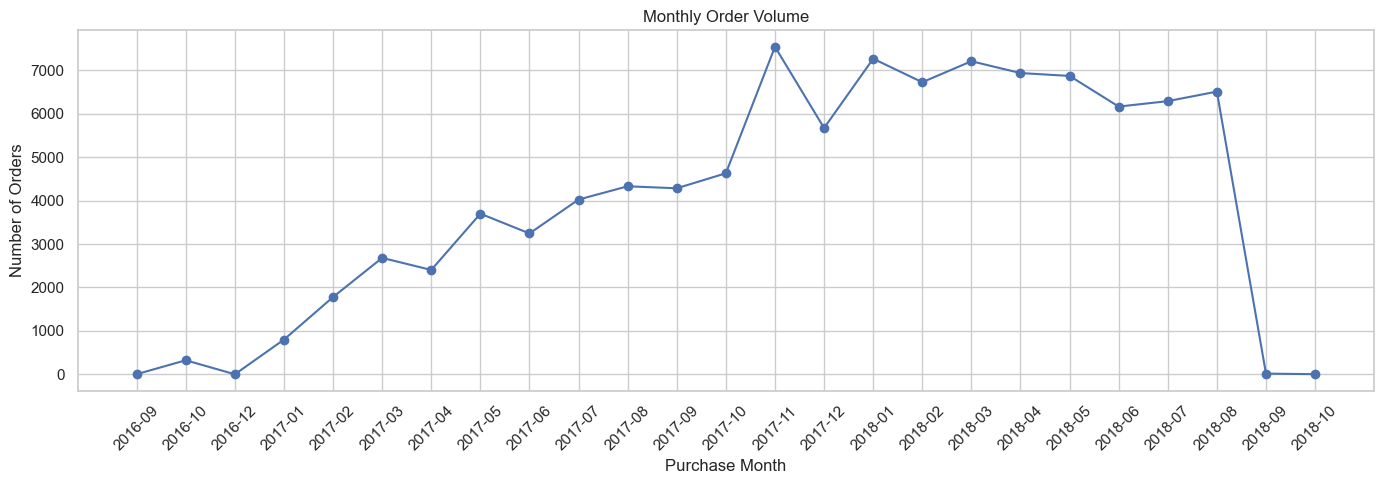

In [24]:
import matplotlib.pyplot as plt

# Plot monthly order volume over time.

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend["purchase_year_month"], monthly_trend["total_orders"], marker="o")
plt.title("Monthly Order Volume")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

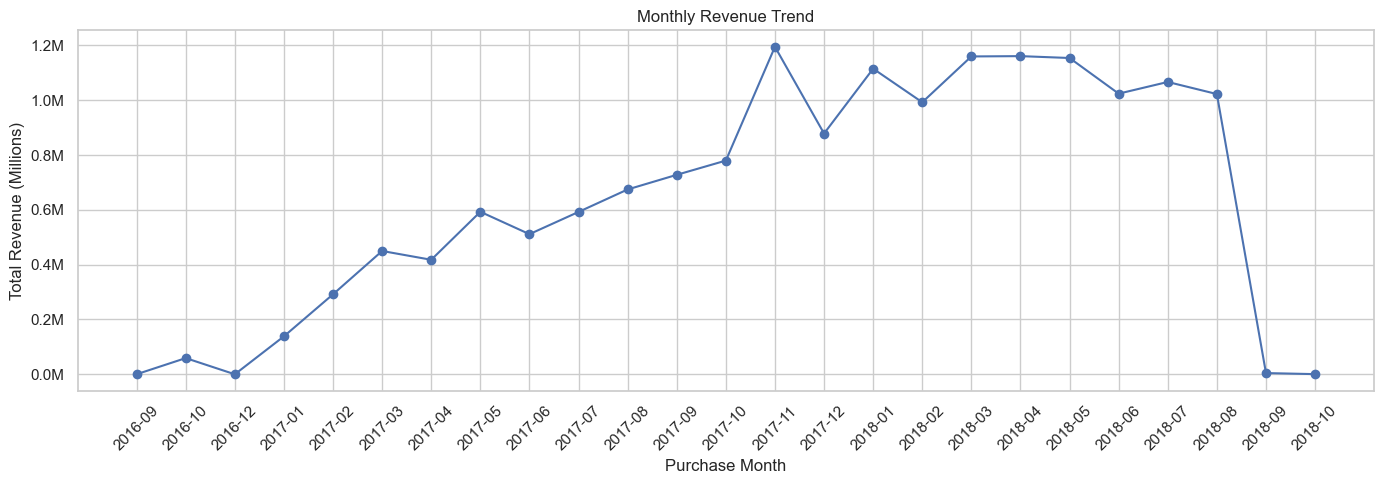

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_trend["purchase_year_month"],
    monthly_trend["total_revenue"],
    marker="o"
)

ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Purchase Month")

format_axis_units(
    ax=ax,
    values=monthly_trend["total_revenue"],
    axis="y",
    label_base="Total Revenue"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

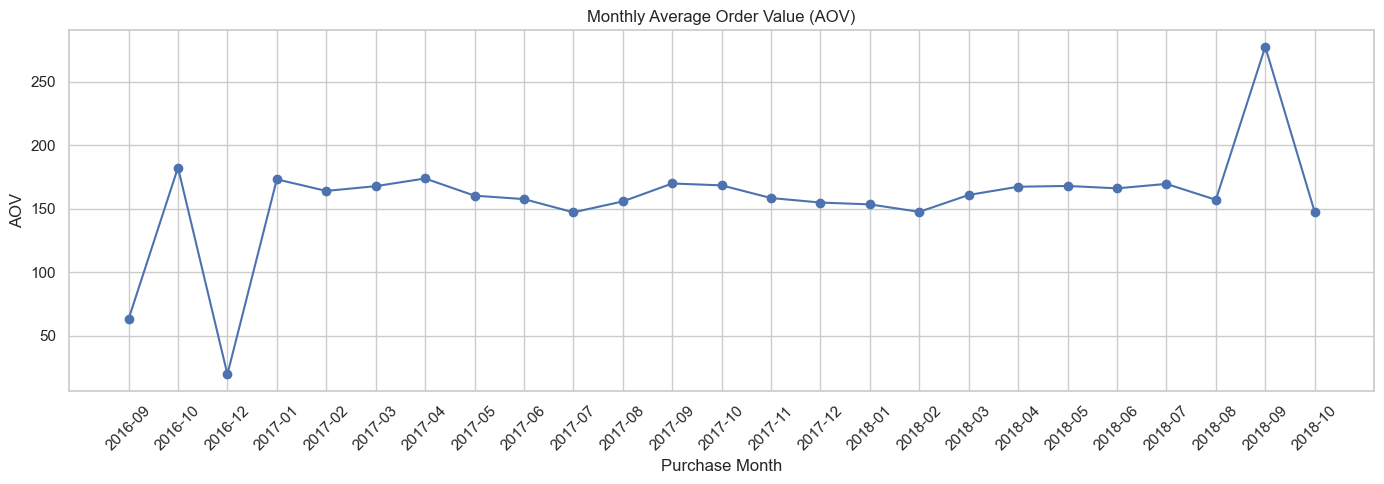

In [26]:
# Plot Average Order Value over time.

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend["purchase_year_month"], monthly_trend["aov"], marker="o")
plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Purchase Month")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Identify top and bottom months by revenue and order volume.

top_revenue_months = monthly_trend.sort_values("total_revenue", ascending=False).head(5)
bottom_revenue_months = monthly_trend.sort_values("total_revenue", ascending=True).head(5)

top_order_months = monthly_trend.sort_values("total_orders", ascending=False).head(5)
bottom_order_months = monthly_trend.sort_values("total_orders", ascending=True).head(5)

print("Top 5 months by revenue")
display(top_revenue_months)

print("Bottom 5 months by revenue")
display(bottom_revenue_months)

print("Top 5 months by order volume")
display(top_order_months)

print("Bottom 5 months by order volume")
display(bottom_order_months)

Top 5 months by revenue


,purchase_year_month,total_orders,total_revenue,aov
13,2017-11,7544,1194882.80,158.39
18,2018-04,6939,1160785.48,167.28
17,2018-03,7211,1159652.12,160.82
19,2018-05,6873,1153982.15,167.90
15,2018-01,7269,1115004.18,153.39


Bottom 5 months by revenue


,purchase_year_month,total_orders,total_revenue,aov
2,2016-12,1,19.62,19.62
0,2016-09,4,252.24,63.06
24,2018-10,4,589.67,147.42
23,2018-09,16,4439.54,277.47
1,2016-10,324,59090.48,182.38


Top 5 months by order volume


,purchase_year_month,total_orders,total_revenue,aov
13,2017-11,7544,1194882.80,158.39
15,2018-01,7269,1115004.18,153.39
17,2018-03,7211,1159652.12,160.82
18,2018-04,6939,1160785.48,167.28
19,2018-05,6873,1153982.15,167.90


Bottom 5 months by order volume


,purchase_year_month,total_orders,total_revenue,aov
2,2016-12,1,19.62,19.62
0,2016-09,4,252.24,63.06
24,2018-10,4,589.67,147.42
23,2018-09,16,4439.54,277.47
1,2016-10,324,59090.48,182.38


## Revenue and Order Trends Analysis

Monthly revenue and order volume were analyzed using the `orders_features` table, which contains one row per order. This ensures that order counts, revenue, and AOV are calculated at the correct order-level grain without duplication.

This section addresses the following business questions:

- How have revenue and order volume changed over time?
- Are there seasonal patterns in sales performance?
- Which periods appear to drive revenue growth?

---

### Key Findings

#### 1. Strong growth phase identified

Order volume and revenue increased steadily throughout **2017**, indicating a successful growth phase after the initial low-volume period in late 2016.

This suggests that the business gained traction during 2017 and moved into a more stable operating phase.

---

#### 2. Peak performance occurred in November 2017

The highest-performing month was **2017-11**, with:

- **7,544 orders**
- **1,194,882.80 total revenue**
- **158.39 average order value (AOV)**

This month ranked first in both revenue and order volume, making it the strongest month in the analyzed period.

---

#### 3. Sustained high performance continued into 2018

From **January 2018 to August 2018**, the business maintained consistently high order volume and revenue.

Several months during this period exceeded or approached **1 million** in revenue, showing that the strong performance was not limited to a single month.

---

#### 4. Revenue growth was mainly driven by order volume

Revenue and order volume moved closely together over time.

At the same time, AOV remained relatively stable during the main active period, generally ranging between approximately **150 and 170**.

This indicates that revenue growth was mainly driven by a higher number of orders rather than a major increase in customer spending per order.

---

#### 5. Customer spending behavior was relatively stable

The consistency of AOV during peak months suggests that customer spending per order remained stable while the business scaled through higher transaction volume.

This is a positive sign because growth appears to come from increased demand rather than unstable changes in average order value.

---

#### 6. Some months reflect partial or low data coverage

Months such as **2016-09**, **2016-12**, **2018-09**, and **2018-10** had very low order counts.

These months should be treated as partial or low-coverage periods and should not be used as standalone evidence for seasonality or normal business performance.

---

#### 7. Reliable analysis window identified

The most reliable period for trend and seasonality analysis is:

**2017-01 to 2018-08**

This period has stable data coverage and meaningful business activity, making it the best window for evaluating growth patterns and seasonal trends.

---

### Top Revenue Months

| Month | Total Orders | Total Revenue | AOV |
|---|---:|---:|---:|
| 2017-11 | 7,544 | 1,194,882.80 | 158.39 |
| 2018-04 | 6,939 | 1,160,785.48 | 167.28 |
| 2018-03 | 7,211 | 1,159,652.12 | 160.82 |
| 2018-05 | 6,873 | 1,153,982.15 | 167.90 |
| 2018-01 | 7,269 | 1,115,004.18 | 153.39 |

---

### Low-Activity Months

| Month | Total Orders | Total Revenue | AOV |
|---|---:|---:|---:|
| 2016-12 | 1 | 19.62 | 19.62 |
| 2016-09 | 4 | 252.24 | 63.06 |
| 2018-10 | 4 | 589.67 | 147.42 |
| 2018-09 | 16 | 4,439.54 | 277.47 |
| 2016-10 | 324 | 59,090.48 | 182.38 |

---

### Trend Interpretation

Monthly order volume increased strongly during 2017 and reached its highest point in **November 2017**.

Revenue followed a similar pattern to order volume, which suggests that revenue growth was primarily driven by the increase in the number of orders.

The business maintained strong performance through early and mid-2018, especially between **January 2018 and August 2018**.

AOV remained relatively stable during this core period, which indicates that customer spending per order was consistent while the business scaled mainly through higher order volume.

---

### Data Coverage Consideration

The months with very low order counts should be interpreted carefully.

The following months are likely partial or low-coverage periods:

- **2016-09**
- **2016-12**
- **2018-09**
- **2018-10**

These months should not be used alone to draw conclusions about seasonality or long-term business performance.

For more reliable trend and seasonality analysis, the recommended analysis window is:

**2017-01 to 2018-08**

---

### Business Interpretation

The business appears to have transitioned from an initial low-volume stage in late 2016 into a clear growth phase during 2017.

The peak in **November 2017** may indicate the impact of seasonal demand, promotional activity, stronger customer acquisition, or category-level growth.

The sustained performance in early and mid-2018 shows that the business maintained momentum after the November 2017 peak.

Because AOV remained relatively stable while revenue increased, the main growth driver was likely higher order volume rather than customers spending significantly more per order.

---

### Recommendation

For future revenue trend and seasonality analysis, focus on the period:

**2017-01 to 2018-08**

Low-coverage months should be excluded or clearly flagged when evaluating seasonality or long-term performance.

Recommended follow-up analyses:

- Analyze revenue and order trends by customer geography.
- Analyze revenue and order trends by product category.
- Investigate whether the November 2017 peak was driven by specific categories, regions, or promotions.
- Compare AOV across customer segments, regions, and product categories.
- Use the reliable analysis window when building dashboard trend visuals.

## 1.2 Revenue and Orders by Geography

This section analyzes growth?This section analyzes revenue and order volume by customer state.
- Which states contribute the most to order volume?
- Are there states with high AOV despite lower order volume?
- Is revenue concentrated in a few major regions?

The objective is to identify which geographic regions contribute the most to sales performance and whether revenue growth is concentrated in specific states.

This analysis supports the following business questions:



In [28]:
# Analyze revenue and order volume by customer state.
# orders_features is used because it has one row per order.

state_revenue_orders = (
    orders_features
    .groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_revenue", "sum")
    )
)

# Calculate Average Order Value (AOV)
state_revenue_orders["aov"] = (
    state_revenue_orders["total_revenue"] / state_revenue_orders["total_orders"]
).round(2)

# Calculate contribution percentages
state_revenue_orders["revenue_percentage"] = (
    state_revenue_orders["total_revenue"] / state_revenue_orders["total_revenue"].sum() * 100
).round(2)

state_revenue_orders["order_percentage"] = (
    state_revenue_orders["total_orders"] / state_revenue_orders["total_orders"].sum() * 100
).round(2)

# Sort by revenue
state_revenue_orders = state_revenue_orders.sort_values(
    "total_revenue",
    ascending=False
)

print("✅ Revenue and orders by customer state created")
display(state_revenue_orders.head(10))

✅ Revenue and orders by customer state created


,customer_state,total_orders,total_revenue,aov,revenue_percentage,order_percentage
25,SP,41746,5998226.96,143.68,37.47,41.98
18,RJ,12852,2144379.69,166.85,13.39,12.92
10,MG,11635,1872257.26,160.92,11.70,11.70
22,RS,5466,890898.54,162.99,5.57,5.50
17,PR,5045,811156.38,160.78,5.07,5.07
23,SC,3637,623086.43,171.32,3.89,3.66
4,BA,3380,616645.82,182.44,3.85,3.40
6,DF,2140,355141.08,165.95,2.22,2.15
8,GO,2020,350092.31,173.31,2.19,2.03
7,ES,2033,325967.55,160.34,2.04,2.04


In [29]:
# Select top 10 states by total revenue.

top_states_by_revenue = state_revenue_orders.head(10).copy()

display(top_states_by_revenue)

,customer_state,total_orders,total_revenue,aov,revenue_percentage,order_percentage
25,SP,41746,5998226.96,143.68,37.47,41.98
18,RJ,12852,2144379.69,166.85,13.39,12.92
10,MG,11635,1872257.26,160.92,11.70,11.70
22,RS,5466,890898.54,162.99,5.57,5.50
17,PR,5045,811156.38,160.78,5.07,5.07
23,SC,3637,623086.43,171.32,3.89,3.66
4,BA,3380,616645.82,182.44,3.85,3.40
6,DF,2140,355141.08,165.95,2.22,2.15
8,GO,2020,350092.31,173.31,2.19,2.03
7,ES,2033,325967.55,160.34,2.04,2.04


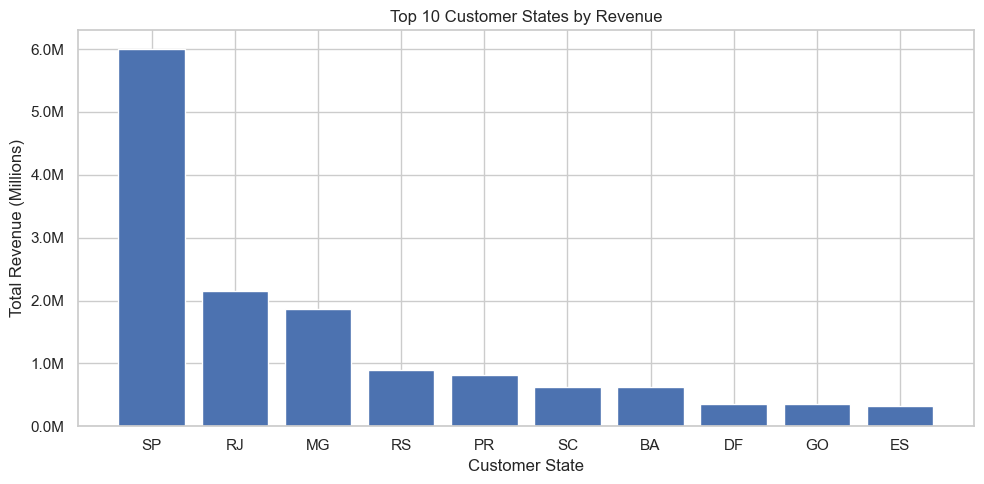

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    top_states_by_revenue["customer_state"],
    top_states_by_revenue["total_revenue"]
)

ax.set_title("Top 10 Customer States by Revenue")
ax.set_xlabel("Customer State")

format_axis_units(
    ax=ax,
    values=top_states_by_revenue["total_revenue"],
    axis="y",
    label_base="Total Revenue"
)

plt.tight_layout()
plt.show()

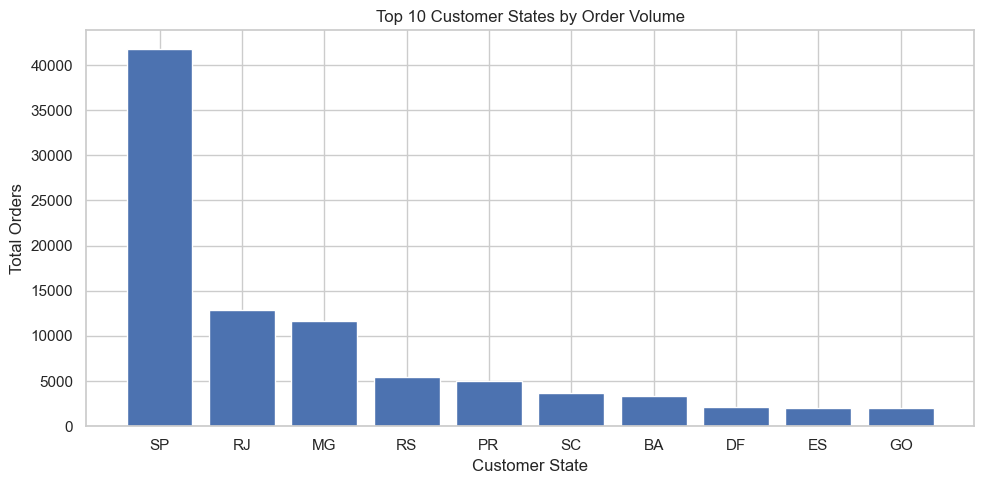

,customer_state,total_orders,total_revenue,aov,revenue_percentage,order_percentage
25,SP,41746,5998226.96,143.68,37.47,41.98
18,RJ,12852,2144379.69,166.85,13.39,12.92
10,MG,11635,1872257.26,160.92,11.70,11.70
22,RS,5466,890898.54,162.99,5.57,5.50
17,PR,5045,811156.38,160.78,5.07,5.07
23,SC,3637,623086.43,171.32,3.89,3.66
4,BA,3380,616645.82,182.44,3.85,3.40
6,DF,2140,355141.08,165.95,2.22,2.15
7,ES,2033,325967.55,160.34,2.04,2.04
8,GO,2020,350092.31,173.31,2.19,2.03


In [31]:
# Plot top 10 states by order volume.

top_states_by_orders = state_revenue_orders.sort_values(
    "total_orders",
    ascending=False
).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_states_by_orders["customer_state"], top_states_by_orders["total_orders"])
plt.title("Top 10 Customer States by Order Volume")
plt.xlabel("Customer State")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

display(top_states_by_orders)

In [32]:
# Analyze states with the highest AOV.
# A minimum order threshold is applied to avoid misleading results from very small samples.

minimum_orders = 100

top_states_by_aov = (
    state_revenue_orders[state_revenue_orders["total_orders"] >= minimum_orders]
    .sort_values("aov", ascending=False)
    .head(10)
)

display(top_states_by_aov)

,customer_state,total_orders,total_revenue,aov,revenue_percentage,order_percentage
14,PB,536,141545.72,264.08,0.88,0.54
20,RO,253,60866.20,240.58,0.38,0.25
1,AL,413,96962.06,234.77,0.61,0.42
13,PA,975,218295.85,223.89,1.36,0.98
26,TO,280,61485.33,219.59,0.38,0.28
16,PI,495,108523.97,219.24,0.68,0.50
24,SE,350,75246.25,214.99,0.47,0.35
19,RN,485,102718.13,211.79,0.64,0.49
5,CE,1336,279464.03,209.18,1.75,1.34
12,MT,907,187029.29,206.21,1.17,0.91


In [33]:
# Measure revenue concentration by customer state.
# This shows how much revenue is driven by the top states.

state_revenue_sorted = state_revenue_orders.sort_values(
    "total_revenue",
    ascending=False
).reset_index(drop=True)

top_3_revenue_share = state_revenue_sorted.head(3)["revenue_percentage"].sum().round(2)
top_5_revenue_share = state_revenue_sorted.head(5)["revenue_percentage"].sum().round(2)
top_10_revenue_share = state_revenue_sorted.head(10)["revenue_percentage"].sum().round(2)

state_revenue_concentration = pd.DataFrame({
    "metric": [
        "Top 3 states revenue share",
        "Top 5 states revenue share",
        "Top 10 states revenue share"
    ],
    "value_percentage": [
        top_3_revenue_share,
        top_5_revenue_share,
        top_10_revenue_share
    ]
})

display(state_revenue_concentration)

,metric,value_percentage
0,Top 3 states revenue share,62.56
1,Top 5 states revenue share,73.20
2,Top 10 states revenue share,87.39


## 2. Revenue and Orders by Geography

Revenue and order volume were analyzed by `customer_state` using the `orders_features` table. This table contains one row per order, ensuring that order counts, revenue, and AOV are calculated at the correct order-level grain without duplication.

This section addresses the following business questions:

- Which geographies drive revenue growth?
- Which states contribute the most to order volume?
- Are there states with high AOV despite lower order volume?
- Is revenue concentrated in a few major regions?

---

### Key Findings

#### 1. Revenue is highly concentrated in a few states

The top revenue-driving state is **SP**, contributing:

- **41,746 orders**
- **5,998,226.96 total revenue**
- **37.47% of total revenue**
- **41.98% of total orders**

This shows that SP is the dominant market in both revenue and order volume.

---

#### 2. The top 3 states generate most of the revenue

The top 3 states by revenue are:

| State | Total Orders | Total Revenue | AOV | Revenue % | Order % |
|---|---:|---:|---:|---:|---:|
| SP | 41,746 | 5,998,226.96 | 143.68 | 37.47% | 41.98% |
| RJ | 12,852 | 2,144,379.69 | 166.85 | 13.39% | 12.92% |
| MG | 11,635 | 1,872,257.26 | 160.92 | 11.70% | 11.70% |

Together, these 3 states contribute **62.56% of total revenue**.

This indicates a strong geographic concentration of sales.

---

#### 3. The top 10 states account for almost all revenue

Revenue concentration by state shows:

| Metric | Revenue Share |
|---|---:|
| Top 3 states revenue share | 62.56% |
| Top 5 states revenue share | 73.20% |
| Top 10 states revenue share | 87.39% |

This means that the majority of revenue is generated by a relatively small number of states.

---

#### 4. Order volume follows a similar geographic pattern

The same major states also dominate order volume.

SP is the clear leader in order count, followed by RJ and MG. This confirms that geographic revenue concentration is primarily driven by order volume, not only by higher AOV.

---

#### 5. Some smaller states show higher AOV

Some states with lower order volume have relatively high AOV.

Top states by AOV, after applying a minimum threshold of 100 orders, include:

| State | Total Orders | Total Revenue | AOV | Revenue % | Order % |
|---|---:|---:|---:|---:|---:|
| PB | 536 | 141,545.72 | 264.08 | 0.88% | 0.54% |
| RO | 253 | 60,866.20 | 240.58 | 0.38% | 0.25% |
| AL | 413 | 96,962.06 | 234.77 | 0.61% | 0.42% |
| PA | 975 | 218,295.85 | 223.89 | 1.36% | 0.98% |
| TO | 280 | 61,485.33 | 219.59 | 0.38% | 0.28% |
| PI | 495 | 108,523.97 | 219.24 | 0.68% | 0.50% |
| SE | 350 | 75,246.25 | 214.99 | 0.47% | 0.35% |
| RN | 485 | 102,718.13 | 211.79 | 0.64% | 0.49% |
| CE | 1,336 | 279,464.03 | 209.18 | 1.75% | 1.34% |
| MT | 907 | 187,029.29 | 206.21 | 1.17% | 0.91% |

These states do not drive the highest total revenue because their order volumes are smaller, but their higher AOV may indicate stronger order value potential.

---

### Business Interpretation

The business is heavily concentrated in **SP, RJ, and MG**, which together generate more than **60% of total revenue**.

SP is the core revenue and order-volume market. However, SP has a lower AOV (**143.68**) compared with several smaller states, suggesting that SP’s revenue strength is mainly volume-driven.

On the other hand, states such as **PB, RO, AL, PA, TO, PI, SE, RN, CE, and MT** show higher AOV despite smaller order volumes. These markets may represent opportunities for targeted growth, premium product positioning, or further investigation into product mix and freight behavior.

The geographic revenue pattern suggests two different strategic groups:

1. **High-volume core markets**  
   States such as SP, RJ, and MG drive most revenue through large order volume.

2. **High-AOV opportunity markets**  
   Smaller states with higher AOV may offer value-growth opportunities if order volume can be increased.

---

### Recommendation

For revenue growth strategy, the business should treat geography as a key segmentation dimension.

Recommended next steps:

- Protect and optimize performance in high-volume markets, especially **SP, RJ, and MG**.
- Investigate what products and categories drive higher AOV in smaller states such as **PB, RO, AL, and PA**.
- Analyze whether higher AOV in smaller states is linked to product mix, freight cost, customer behavior, or lower competition.
- Compare delivery performance by state to identify whether logistics constraints affect growth in high-AOV regions.
- Use state-level segmentation in dashboard filters to separate volume-driven markets from value-driven markets.

## 2.Product and Category Performance Analysis

This section analyzes product category performance using item-level and order-level feature tables.

The goal is to identify which categories drive revenue and order volume, and which categories may require business attention due to low ratings, low sales, or operational issues.

This analysis supports the following business questions:

- Which categories generate the highest revenue and order volume?
- Which categories underperform in sales, ratings, or delivery performance?
- Which categories should be prioritized for growth or operational improvement?

In [34]:
# Create order-level review scores.
# This avoids duplicating review information when joining with category-level data.

reviews_order_level = (
    core_reviews
    .groupby("order_id", as_index=False)
    .agg(
        avg_review_score=("review_score", "mean"),
        review_count=("review_id", "nunique")
    )
)

print("✅ Order-level review scores created")
display(reviews_order_level.head())

✅ Order-level review scores created


,order_id,avg_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [35]:
# Create order-category level table.
# This table has one row per order and category combination.

order_category_features = (
    order_items_category_features
    .groupby(["order_id", "product_category_name_english"], as_index=False)
    .agg(
        category_revenue=("item_total_value", "sum"),
        category_item_count=("order_item_id", "count"),
        unique_products_in_category=("product_id", "nunique")
    )
)

# Add order-level context: purchase month, customer state, delivery flag
order_category_features = order_category_features.merge(
    orders_features[
        [
            "order_id",
            "purchase_year_month",
            "customer_state",
            "is_late_delivery"
        ]
    ],
    on="order_id",
    how="left"
)

# Add order-level review score
order_category_features = order_category_features.merge(
    reviews_order_level,
    on="order_id",
    how="left"
)

print("✅ Order-category feature table created")
print("Rows:", len(order_category_features))
display(order_category_features.head())

✅ Order-category feature table created
Rows: 99470


,order_id,product_category_name_english,category_revenue,category_item_count,unique_products_in_category,purchase_year_month,customer_state,is_late_delivery,avg_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,72.19,1,1,2017-09,RJ,False,5.0,1.0
1,00018f77f2f0320c557190d7a144bdd3,pet_shop,259.83,1,1,2017-04,SP,False,4.0,1.0
2,000229ec398224ef6ca0657da4fc703e,furniture_decor,216.87,1,1,2018-01,MG,False,5.0,1.0
3,00024acbcdf0a6daa1e931b038114c75,perfumery,25.78,1,1,2018-08,SP,False,4.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,218.04,1,1,2017-02,SP,False,5.0,1.0


In [36]:
# Summarize product category performance.
# This table supports revenue, volume, satisfaction, and delivery analysis by category.

category_performance = (
    order_category_features
    .groupby("product_category_name_english", as_index=False)
    .agg(
        total_revenue=("category_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_items=("category_item_count", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        late_delivery_rate=("is_late_delivery", "mean")
    )
)

# Calculate average revenue per order for each category
category_performance["avg_category_order_value"] = (
    category_performance["total_revenue"] / category_performance["total_orders"]
).round(2)

# Convert late delivery rate to percentage
category_performance["late_delivery_rate_pct"] = (
    category_performance["late_delivery_rate"] * 100
).round(2)

# Round review score
category_performance["avg_review_score"] = category_performance["avg_review_score"].round(2)

# Sort by revenue
category_performance = category_performance.sort_values(
    "total_revenue",
    ascending=False
)

print("✅ Category performance summary created")
display(category_performance.head(10))

✅ Category performance summary created


,product_category_name_english,total_revenue,total_orders,total_items,avg_review_score,late_delivery_rate,avg_category_order_value,late_delivery_rate_pct
45,health_beauty,1441248.07,8836,9670,4.18,0.073563,163.11,7.36
73,watches_gifts,1305541.61,5624,5991,4.07,0.072191,232.14,7.22
9,bed_bath_table,1241681.72,9417,11115,3.97,0.073166,131.86,7.32
67,sports_leisure,1156656.48,7720,8641,4.17,0.064119,149.83,6.41
17,computers_accessories,1059272.40,6689,7827,4.03,0.062341,158.36,6.23
41,furniture_decor,902511.79,6449,8334,4.01,0.069623,139.95,6.96
51,housewares,778397.77,5884,6964,4.14,0.052345,132.29,5.23
22,cool_stuff,719329.95,3632,3796,4.17,0.057819,198.05,5.78
7,auto,685384.32,3897,4235,4.09,0.071337,175.87,7.13
44,garden_tools,584219.21,3518,4347,4.14,0.063957,166.07,6.40


In [37]:
# Select top 10 product categories by total revenue.

top_categories_by_revenue = category_performance.head(10).copy()

display(top_categories_by_revenue)

,product_category_name_english,total_revenue,total_orders,total_items,avg_review_score,late_delivery_rate,avg_category_order_value,late_delivery_rate_pct
45,health_beauty,1441248.07,8836,9670,4.18,0.073563,163.11,7.36
73,watches_gifts,1305541.61,5624,5991,4.07,0.072191,232.14,7.22
9,bed_bath_table,1241681.72,9417,11115,3.97,0.073166,131.86,7.32
67,sports_leisure,1156656.48,7720,8641,4.17,0.064119,149.83,6.41
17,computers_accessories,1059272.40,6689,7827,4.03,0.062341,158.36,6.23
41,furniture_decor,902511.79,6449,8334,4.01,0.069623,139.95,6.96
51,housewares,778397.77,5884,6964,4.14,0.052345,132.29,5.23
22,cool_stuff,719329.95,3632,3796,4.17,0.057819,198.05,5.78
7,auto,685384.32,3897,4235,4.09,0.071337,175.87,7.13
44,garden_tools,584219.21,3518,4347,4.14,0.063957,166.07,6.40


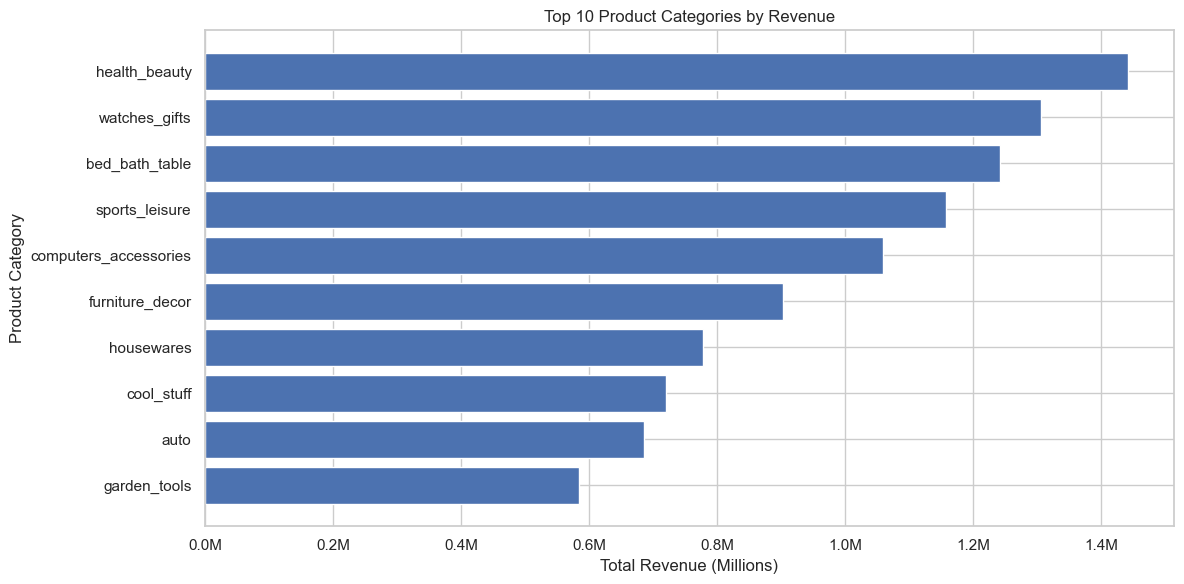

In [38]:
import matplotlib.pyplot as plt

# Plot top 10 categories by revenue.

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top_categories_by_revenue["product_category_name_english"],
    top_categories_by_revenue["total_revenue"]
)

ax.set_title("Top 10 Product Categories by Revenue")
ax.set_xlabel("Total Revenue")
ax.set_ylabel("Product Category")

# Format revenue axis if the helper function exists
try:
    format_axis_units(
        ax=ax,
        values=top_categories_by_revenue["total_revenue"],
        axis="x",
        label_base="Total Revenue"
    )
except NameError:
    pass

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
# Select top 10 product categories by order volume.

top_categories_by_orders = (
    category_performance
    .sort_values("total_orders", ascending=False)
    .head(10)
)

display(top_categories_by_orders)

,product_category_name_english,total_revenue,total_orders,total_items,avg_review_score,late_delivery_rate,avg_category_order_value,late_delivery_rate_pct
9,bed_bath_table,1241681.72,9417,11115,3.97,0.073166,131.86,7.32
45,health_beauty,1441248.07,8836,9670,4.18,0.073563,163.11,7.36
67,sports_leisure,1156656.48,7720,8641,4.17,0.064119,149.83,6.41
17,computers_accessories,1059272.40,6689,7827,4.03,0.062341,158.36,6.23
41,furniture_decor,902511.79,6449,8334,4.01,0.069623,139.95,6.96
51,housewares,778397.77,5884,6964,4.14,0.052345,132.29,5.23
73,watches_gifts,1305541.61,5624,5991,4.07,0.072191,232.14,7.22
70,telephony,394883.32,4199,4545,4.00,0.069302,94.04,6.93
7,auto,685384.32,3897,4235,4.09,0.071337,175.87,7.13
71,toys,561372.55,3886,4117,4.19,0.062532,144.46,6.25


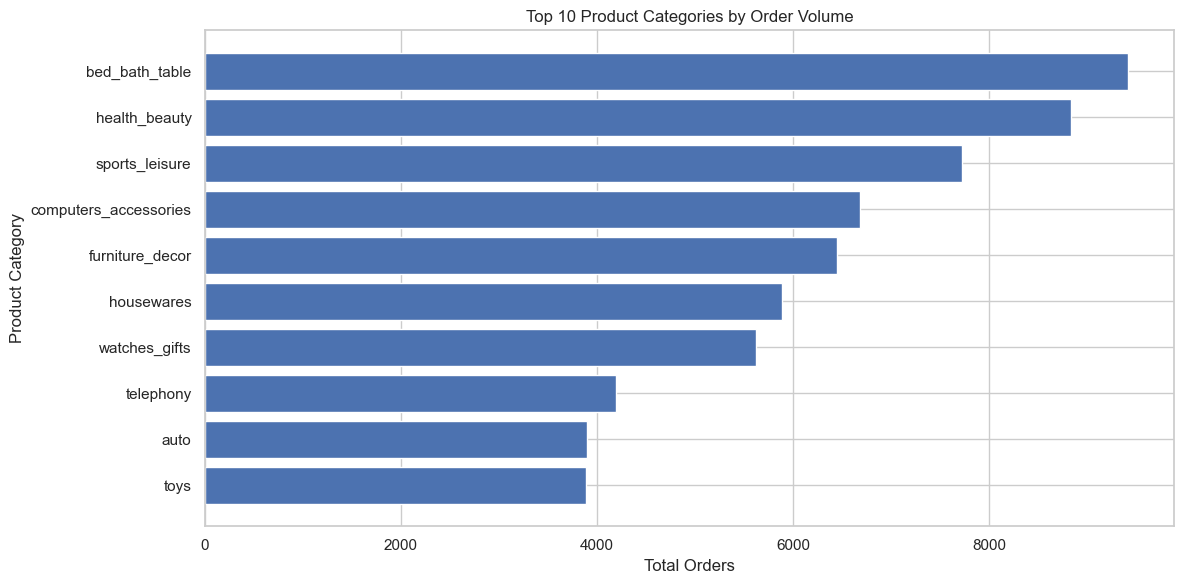

In [40]:
# Plot top 10 categories by order volume.

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    top_categories_by_orders["product_category_name_english"],
    top_categories_by_orders["total_orders"]
)

ax.set_title("Top 10 Product Categories by Order Volume")
ax.set_xlabel("Total Orders")
ax.set_ylabel("Product Category")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [41]:
# Identify categories with the lowest average review score.
# A minimum order threshold is applied to avoid misleading results from small samples.

minimum_orders = 100

low_rated_categories = (
    category_performance[
        category_performance["total_orders"] >= minimum_orders
    ]
    .sort_values("avg_review_score", ascending=True)
    .head(10)
)

display(low_rated_categories)

,product_category_name_english,total_revenue,total_orders,total_items,avg_review_score,late_delivery_rate,avg_category_order_value,late_delivery_rate_pct
59,office_furniture,342532.65,1273,1691,3.62,0.079340,269.08,7.93
32,fashion_male_clothing,12950.23,112,132,3.70,0.044643,115.63,4.46
6,audio,56398.94,350,364,3.83,0.117143,161.14,11.71
21,construction_tools_safety,44463.62,167,194,3.85,0.023952,266.25,2.40
49,home_confort,67073.27,397,434,3.86,0.093199,168.95,9.32
36,fixed_telephony,64220.81,217,264,3.90,0.046083,295.95,4.61
72,unknown,207705.09,1451,1603,3.91,0.069607,143.15,6.96
35,fashion_underwear_beach,11457.74,121,131,3.93,0.090909,94.69,9.09
9,bed_bath_table,1241681.72,9417,11115,3.97,0.073166,131.86,7.32
50,home_construction,96920.36,490,604,3.97,0.059184,197.80,5.92


In [42]:
# Identify categories with the highest late delivery rate.
# A minimum order threshold is applied to focus on meaningful category volumes.

high_late_delivery_categories = (
    category_performance[
        category_performance["total_orders"] >= minimum_orders
    ]
    .sort_values("late_delivery_rate_pct", ascending=False)
    .head(10)
)

display(high_late_delivery_categories)

,product_category_name_english,total_revenue,total_orders,total_items,avg_review_score,late_delivery_rate,avg_category_order_value,late_delivery_rate_pct
6,audio,56398.94,350,364,3.83,0.117143,161.14,11.71
49,home_confort,67073.27,397,434,3.86,0.093199,168.95,9.32
35,fashion_underwear_beach,11457.74,121,131,3.93,0.090909,94.69,9.09
12,books_technical,23379.12,260,267,4.40,0.080769,89.92,8.08
59,office_furniture,342532.65,1273,1691,3.62,0.079340,269.08,7.93
8,baby,480118.00,2885,3065,4.04,0.078336,166.42,7.83
14,christmas_supplies,12030.12,128,153,4.06,0.078125,93.99,7.81
28,electronics,206825.06,2550,2767,4.10,0.075294,81.11,7.53
45,health_beauty,1441248.07,8836,9670,4.18,0.073563,163.11,7.36
42,furniture_living_room,86884.73,422,503,4.03,0.073460,205.89,7.35


In [43]:
# Measure revenue concentration by product category.

category_revenue_sorted = category_performance.sort_values(
    "total_revenue",
    ascending=False
).reset_index(drop=True)

category_revenue_sorted["revenue_percentage"] = (
    category_revenue_sorted["total_revenue"] /
    category_revenue_sorted["total_revenue"].sum() * 100
).round(2)

top_3_category_revenue_share = category_revenue_sorted.head(3)["revenue_percentage"].sum().round(2)
top_5_category_revenue_share = category_revenue_sorted.head(5)["revenue_percentage"].sum().round(2)
top_10_category_revenue_share = category_revenue_sorted.head(10)["revenue_percentage"].sum().round(2)

category_revenue_concentration = pd.DataFrame({
    "metric": [
        "Top 3 categories revenue share",
        "Top 5 categories revenue share",
        "Top 10 categories revenue share"
    ],
    "value_percentage": [
        top_3_category_revenue_share,
        top_5_category_revenue_share,
        top_10_category_revenue_share
    ]
})

display(category_revenue_concentration)

,metric,value_percentage
0,Top 3 categories revenue share,25.18
1,Top 5 categories revenue share,39.17
2,Top 10 categories revenue share,62.34


## 3. Product and Category Performance Analysis

This section evaluates product category performance using item-level and order-level data.  
The analysis focuses on revenue contribution, order volume, customer satisfaction, and delivery performance to identify high-performing categories and those requiring business or operational attention.

---

### Key Findings

#### 1. Revenue is driven by a small number of categories

The top revenue-generating categories are:

| Category | Total Revenue | Total Orders | AOV | Avg Review | Late Delivery % |
|---|---:|---:|---:|---:|---:|
| Health & Beauty | 1.44M | 8,836 | 163.11 | 4.18 | 7.36% |
| Watches & Gifts | 1.31M | 5,624 | 232.14 | 4.07 | 7.22% |
| Bed Bath & Table | 1.24M | 9,417 | 131.86 | 3.97 | 7.32% |
| Sports & Leisure | 1.16M | 7,720 | 149.83 | 4.17 | 6.41% |
| Computers & Accessories | 1.06M | 6,689 | 158.36 | 4.03 | 6.23% |

These categories represent the core revenue drivers of the business.

---

#### 2. Revenue concentration at the category level

Revenue is moderately concentrated across categories:

| Metric | Revenue Share |
|---|---:|
| Top 3 categories | 25.18% |
| Top 5 categories | 39.17% |
| Top 10 categories | 62.34% |

This indicates that while revenue is not overly dependent on a single category, a limited group of categories accounts for the majority of sales.

---

#### 3. Order volume leaders differ slightly from revenue leaders

Categories with the highest order volume include:

- Bed Bath & Table
- Health & Beauty
- Sports & Leisure
- Computers & Accessories

This confirms that some categories generate revenue primarily through **high order volume**, while others (such as Watches & Gifts) rely more on **higher AOV**.

---

#### 4. Customer satisfaction is generally strong across major categories

Most high-revenue categories maintain average review scores close to or above **4.0**, indicating solid customer satisfaction.

However, some high-volume categories such as **Bed Bath & Table** show slightly lower average ratings, suggesting potential experience or quality issues at scale.

---

#### 5. Categories with low review scores require attention

Categories with the lowest average review scores (minimum 100 orders) include:

- Office Furniture (avg score ~3.62)
- Audio
- Home Comfort
- Fashion Underwear & Beachwear

These categories are candidates for deeper investigation into product quality, expectations, or post-purchase experience.

---

#### 6. Delivery performance varies by category

Categories with the highest late delivery rates include:

- Audio (~11.7%)
- Home Comfort
- Fashion Underwear & Beachwear
- Office Furniture

Some of these categories also exhibit lower review scores, suggesting a possible relationship between delivery delays and customer dissatisfaction.

---

### Business Interpretation

The business is supported by a set of strong, diversified core categories rather than reliance on a single product group.

Two distinct patterns emerge:

1. **High-volume core categories**  
   Categories such as Health & Beauty and Bed Bath & Table generate revenue primarily through large order volume.

2. **High-value categories**  
   Categories such as Watches & Gifts generate strong revenue with fewer orders due to higher AOV.

Operational challenges, particularly delivery delays, appear to be more pronounced in certain categories and may contribute to lower customer ratings in those segments.

---

### Recommendation

- Maintain and protect performance in core revenue categories, especially **Health & Beauty**, **Watches & Gifts**, and **Bed Bath & Table**.
- Investigate categories with low average review scores to identify product quality or expectation issues.
- Review logistics and fulfillment processes for categories with high late delivery rates.
- Segment categories into *volume-driven* and *value-driven* groups in dashboards and reporting.
- Use category-level insights to guide assortment optimization, promotion strategy, and operational improvement initiatives.

---

### Next Step

Proceed to **Delivery Performance and Customer Satisfaction Analysis** to evaluate how delivery delays impact review scores across regions, categories, and sellers.

## 4. Delivery Performance and Customer Satisfaction Analysis

This section evaluates delivery performance and its impact on customer satisfaction.

The analysis focuses on identifying late delivery patterns and understanding how delivery delays affect customer review scores across orders, categories, and regions.

This section supports the following business questions:

- What is the late delivery rate across the business?
- How do delivery delays affect customer satisfaction?
- Which regions and categories experience the most delivery issues?
- Are delivery delays a potential driver of low review scores?

In [44]:
# Calculate overall late delivery rate.

overall_late_delivery_rate = orders_features["is_late_delivery"].mean() * 100

overall_avg_review_score = reviews_order_level["avg_review_score"].mean()

delivery_overview = pd.DataFrame({
    "metric": [
        "Overall Late Delivery Rate (%)",
        "Overall Average Review Score"
    ],
    "value": [
        round(overall_late_delivery_rate, 2),
        round(overall_avg_review_score, 2)
    ]
})

display(delivery_overview)

,metric,value
0,Overall Late Delivery Rate (%),6.57
1,Overall Average Review Score,4.09


In [45]:
# Compare review scores for late vs on-time deliveries.

delivery_review_impact = (
    orders_features
    .merge(reviews_order_level, on="order_id", how="left")
    .groupby("is_late_delivery", as_index=False)
    .agg(
        avg_review_score=("avg_review_score", "mean"),
        order_count=("order_id", "nunique")
    )
)

delivery_review_impact["avg_review_score"] = delivery_review_impact["avg_review_score"].round(2)

display(delivery_review_impact)

,is_late_delivery,avg_review_score,order_count
0,False,4.21,92906
1,True,2.27,6535


In [46]:
# Analyze late delivery rate by customer state.

state_delivery_performance = (
    orders_features
    .groupby("customer_state", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        late_delivery_rate=("is_late_delivery", "mean")
    )
)

state_delivery_performance["late_delivery_rate_pct"] = (
    state_delivery_performance["late_delivery_rate"] * 100
).round(2)

# Filter states with sufficient volume
state_delivery_performance = state_delivery_performance[
    state_delivery_performance["total_orders"] >= 100
].sort_values(
    "late_delivery_rate_pct", ascending=False
)

display(state_delivery_performance.head(10))

,customer_state,total_orders,late_delivery_rate,late_delivery_rate_pct
1,AL,413,0.205811,20.58
9,MA,747,0.167336,16.73
24,SE,350,0.145714,14.57
16,PI,495,0.133333,13.33
5,CE,1336,0.131737,13.17
4,BA,3380,0.117160,11.72
18,RJ,12852,0.116324,11.63
13,PA,975,0.108718,10.87
7,ES,2033,0.105263,10.53
14,PB,536,0.100746,10.07


In [47]:
# Analyze late delivery rate by product category.

category_delivery_performance = (
    order_category_features
    .groupby("product_category_name_english", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_review_score=("avg_review_score", "mean")
    )
)

category_delivery_performance["late_delivery_rate_pct"] = (
    category_delivery_performance["late_delivery_rate"] * 100
).round(2)

category_delivery_performance["avg_review_score"] = (
    category_delivery_performance["avg_review_score"].round(2)
)

category_delivery_performance = category_delivery_performance[
    category_delivery_performance["total_orders"] >= 100
].sort_values(
    "late_delivery_rate_pct", ascending=False
)

display(category_delivery_performance.head(10))


,product_category_name_english,total_orders,late_delivery_rate,avg_review_score,late_delivery_rate_pct
6,audio,350,0.117143,3.83,11.71
49,home_confort,397,0.093199,3.86,9.32
35,fashion_underwear_beach,121,0.090909,3.93,9.09
12,books_technical,260,0.080769,4.40,8.08
59,office_furniture,1273,0.079340,3.62,7.93
8,baby,2885,0.078336,4.04,7.83
14,christmas_supplies,128,0.078125,4.06,7.81
28,electronics,2550,0.075294,4.10,7.53
45,health_beauty,8836,0.073563,4.18,7.36
42,furniture_living_room,422,0.073460,4.03,7.35


In [48]:
# Analyze review score by delivery delay days.

delay_vs_review = (
    orders_features
    .merge(reviews_order_level, on="order_id", how="left")
    .dropna(subset=["delivery_delay_days", "avg_review_score"])
)

delay_vs_review["delay_bucket"] = pd.cut(
    delay_vs_review["delivery_delay_days"],
    bins=[-30, -1, 0, 3, 7, 14, 30, 365],
    labels=[
        "Early",
        "On Time",
        "0–3 Days Late",
        "4–7 Days Late",
        "8–14 Days Late",
        "15–30 Days Late",
        "31+ Days Late"
    ]
)

delay_bucket_summary = (
    delay_vs_review
    .groupby("delay_bucket", as_index=False)
    .agg(
        avg_review_score=("avg_review_score", "mean"),
        orders=("order_id", "nunique")
    )
)

delay_bucket_summary["avg_review_score"] = delay_bucket_summary["avg_review_score"].round(2)

display(delay_bucket_summary)

,delay_bucket,avg_review_score,orders
0,Early,4.30,85452
1,On Time,4.04,1280
2,0–3 Days Late,3.29,1852
3,4–7 Days Late,2.11,1748
4,8–14 Days Late,1.67,1446
5,15–30 Days Late,1.62,1006
6,31+ Days Late,2.06,329


## Delivery Performance and Customer Satisfaction Analysis

This section evaluates delivery performance and its impact on customer satisfaction.

The analysis focuses on late delivery behavior across orders, regions, and product categories, and examines how delivery delays affect customer review scores.

This section addresses the following business questions:

- What is the overall late delivery rate?
- How do delivery delays affect customer satisfaction?
- Which regions and categories experience the most delivery delays?
- Are logistics issues a key driver of low review scores?

---

### Key Findings

#### 1. Late delivery affects a minority of orders, but has a major impact on satisfaction

Across the full dataset:

- **Overall late delivery rate:** **6.57%**
- **Overall average review score:** **4.09 / 5**

While late deliveries represent a relatively small percentage of total orders, their impact on customer satisfaction is significant.

---

#### 2. Late deliveries drastically reduce customer review scores

Customer satisfaction drops sharply when an order is delivered late:

| Delivery Status | Avg Review Score | Orders |
|---|---:|---:|
| On-time deliveries | **4.21** | 92,906 |
| Late deliveries | **2.27** | 6,535 |

This shows a drop of nearly **2 full rating points** for late deliveries.

Delivery timeliness is therefore one of the strongest drivers of negative customer feedback.

---

#### 3. Delays longer than a few days severely damage customer satisfaction

Review scores decline consistently as delivery delay increases:

| Delivery Delay | Avg Review Score | Orders |
|---|---:|---:|
| Early delivery | 4.30 | 85,452 |
| On-time | 4.04 | 1,280 |
| 0–3 days late | 3.29 | 1,852 |
| 4–7 days late | 2.11 | 1,748 |
| 8–14 days late | 1.67 | 1,446 |
| 15–30 days late | 1.62 | 1,006 |
| 31+ days late | 2.06 | 329 |

Delays beyond **3 days** lead to a sharp deterioration in review scores, indicating poor customer tolerance for prolonged delivery issues.

---

#### 4. Late delivery rates vary strongly by region

The highest late delivery rates by customer state (minimum 100 orders) include:

| State | Late Delivery Rate |
|---|---:|
| AL | **20.58%** |
| MA | 16.73% |
| SE | 14.57% |
| PI | 13.33% |
| CE | 13.17% |
| BA | 11.72% |
| RJ | 11.63% |

Some regions show late delivery rates **2–3 times higher** than the overall average of 6.57%.

This indicates regional logistics or distance-related challenges affecting delivery performance.

---

#### 5. Certain product categories suffer from higher delivery delays

Categories with the highest late delivery rates (minimum 100 orders) include:

| Category | Late Delivery Rate | Avg Review Score |
|---|---:|---:|
| Audio | **11.71%** | 3.83 |
| Home Comfort | 9.32% | 3.86 |
| Fashion Underwear & Beachwear | 9.09% | 3.93 |
| Office Furniture | 7.93% | 3.62 |
| Baby | 7.83% | 4.04 |

Several of these categories also show **lower average review scores**, suggesting a direct relationship between delivery challenges and customer dissatisfaction.

---

### Business Interpretation

Delivery performance is a critical driver of customer satisfaction.

Although only a small percentage of orders are delivered late, late delivery has a disproportionate negative impact on review scores.

Key insights include:

- Customers are tolerant of minor deviations, but satisfaction drops significantly after **3 days of delay**.
- Delivery issues are not evenly distributed; some regions and categories experience substantially higher delay rates.
- Categories with complex logistics (e.g., large, fragile, or bulky items) appear more prone to delays and lower satisfaction.

This indicates that customer dissatisfaction in many cases is driven by **operational and logistics issues**, not necessarily by product quality.

---

### Recommendation

To improve customer satisfaction and reduce negative reviews:

- Prioritize reducing late deliveries, especially delays exceeding **3 days**.
- Investigate regional logistics challenges in high-delay states such as **AL, MA, SE, PI, and CE**.
- Review fulfillment and shipping processes for high-risk categories like **Audio**, **Office Furniture**, and **Home Comfort**.
- Incorporate delivery performance KPIs into seller and logistics performance monitoring.
- Use delivery timeliness as a key operational metric in dashboards and performance reviews.

Improving delivery execution represents one of the highest-impact opportunities to improve customer satisfaction at scale.

---

### Next Step

Proceed to **Customer Segmentation and Loyalty Analysis (RFM & Repeat Behavior)** to understand how customer value and loyalty interact with delivery experience and overall business performance.


## 5.Customer Segmentation and Loyalty Analysis (RFM)

This section analyzes customer behavior using RFM segmentation and repeat purchase analysis.

The goal is to identify high-value customers, understand revenue concentration, and distinguish between loyal, at-risk, and low-engagement customer segments.

This analysis supports the following business questions:

- Which customer segments generate the most revenue?
- How important are repeat customers to overall business performance?
- Which customers are loyal, and which customers are at risk of churn?
- How concentrated is revenue among top customer segments?

In [49]:
# Analyze customer distribution by RFM segment.

rfm_customer_distribution = (
    customer_features
    .groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count")
    )
)

rfm_customer_distribution["customer_percentage"] = (
    rfm_customer_distribution["customer_count"] /
    rfm_customer_distribution["customer_count"].sum() * 100
).round(2)

rfm_customer_distribution = rfm_customer_distribution.sort_values(
    "customer_count", ascending=False
)

display(rfm_customer_distribution)

,rfm_segment,customer_count,customer_percentage
0,At Risk,23012,23.95
3,Loyal Customers,16445,17.11
2,Hibernating,15426,16.05
6,Potential Loyalists,15404,16.03
5,Others,15312,15.93
1,Champions,6668,6.94
4,New Customers,3829,3.98


In [50]:
# Analyze revenue contribution by RFM segment.

rfm_revenue_contribution = (
    customer_features
    .groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue_per_customer=("total_revenue", "mean")
    )
)

rfm_revenue_contribution["revenue_percentage"] = (
    rfm_revenue_contribution["total_revenue"] /
    rfm_revenue_contribution["total_revenue"].sum() * 100
).round(2)

rfm_revenue_contribution["avg_revenue_per_customer"] = (
    rfm_revenue_contribution["avg_revenue_per_customer"].round(2)
)

rfm_revenue_contribution = rfm_revenue_contribution.sort_values(
    "total_revenue", ascending=False
)

display(rfm_revenue_contribution)

,rfm_segment,customer_count,total_revenue,avg_revenue_per_customer,revenue_percentage
0,At Risk,23012,3880999.99,168.65,24.24
6,Potential Loyalists,15404,2550606.28,165.58,15.93
2,Hibernating,15426,2532878.43,164.20,15.82
5,Others,15312,2392809.80,156.27,14.95
1,Champions,6668,2118493.52,317.71,13.23
3,Loyal Customers,16445,1912182.42,116.28,11.94
4,New Customers,3829,620901.68,162.16,3.88


In [51]:
# Analyze revenue and order contribution by repeat vs one-time customers.

repeat_customer_analysis = (
    customer_features
    .groupby("is_repeat_customer", as_index=False)
    .agg(
        customer_count=("customer_unique_id", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_customer_value=("total_revenue", "mean")
    )
)

repeat_customer_analysis["customer_percentage"] = (
    repeat_customer_analysis["customer_count"] /
    repeat_customer_analysis["customer_count"].sum() * 100
).round(2)

repeat_customer_analysis["revenue_percentage"] = (
    repeat_customer_analysis["total_revenue"] /
    repeat_customer_analysis["total_revenue"].sum() * 100
).round(2)

repeat_customer_analysis["avg_customer_value"] = (
    repeat_customer_analysis["avg_customer_value"].round(2)
)

display(repeat_customer_analysis)

,is_repeat_customer,customer_count,total_revenue,avg_customer_value,customer_percentage,revenue_percentage
0,False,93099,15064849.41,161.82,96.88,94.1
1,True,2997,944022.71,314.99,3.12,5.9


In [52]:
# Analyze average number of orders per customer by RFM segment.

orders_per_segment = (
    customer_features
    .groupby("rfm_segment", as_index=False)
    .agg(
        avg_orders_per_customer=("total_orders", "mean"),
        avg_customer_tenure=("customer_tenure_days", "mean")
    )
)

orders_per_segment["avg_orders_per_customer"] = (
    orders_per_segment["avg_orders_per_customer"].round(2)
)

orders_per_segment["avg_customer_tenure"] = (
    orders_per_segment["avg_customer_tenure"].round(0)
)

display(orders_per_segment)

,rfm_segment,avg_orders_per_customer,avg_customer_tenure
0,At Risk,1.05,2.0
1,Champions,1.19,22.0
2,Hibernating,1.00,0.0
3,Loyal Customers,1.06,5.0
4,New Customers,1.00,0.0
5,Others,1.00,0.0
6,Potential Loyalists,1.00,0.0


In [53]:
# Analyze customer revenue concentration.

customer_revenue_sorted = (
    customer_features
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

customer_revenue_sorted["revenue_percentage"] = (
    customer_revenue_sorted["total_revenue"] /
    customer_revenue_sorted["total_revenue"].sum() * 100
)

top_10pct_revenue = (
    customer_revenue_sorted
    .head(int(len(customer_revenue_sorted) * 0.10))
    ["revenue_percentage"]
    .sum()
    .round(2)
)

top_20pct_revenue = (
    customer_revenue_sorted
    .head(int(len(customer_revenue_sorted) * 0.20))
    ["revenue_percentage"]
    .sum()
    .round(2)
)

revenue_concentration_customers = pd.DataFrame({
    "metric": [
        "Top 10% customers revenue share",
        "Top 20% customers revenue share"
    ],
    "value_percentage": [
        top_10pct_revenue,
        top_20pct_revenue
    ]
})

display(revenue_concentration_customers)

,metric,value_percentage
0,Top 10% customers revenue share,38.51
1,Top 20% customers revenue share,53.77


## Customer Segmentation and Loyalty Analysis (RFM)

This section analyzes customer behavior using RFM segmentation and repeat purchase analysis.

The objective is to identify high-value customers, understand revenue concentration, and distinguish between loyal customers, new customers, and customers at risk of churn.

This section addresses the following business questions:

- Which customer segments generate the most revenue?
- How important are repeat customers to overall business performance?
- Which customers are loyal, and which customers are at risk?
- How concentrated is revenue among top customers?

---

### Key Findings

#### 1. The customer base is dominated by single‑purchase behavior

The majority of customers fall into low‑frequency segments:

| Segment | Customer % |
|---|---:|
| At Risk | 23.95% |
| Hibernating | 16.05% |
| Potential Loyalists | 16.03% |
| Others | 15.93% |
| Loyal Customers | 17.11% |
| Champions | 6.94% |
| New Customers | 3.98% |

More than **55%** of customers belong to **At Risk**, **Hibernating**, or **Potential Loyalist** segments, indicating significant churn risk and limited repeat purchasing behavior.

---

#### 2. Revenue is not driven primarily by loyal customers

Revenue contribution by RFM segment shows a surprising pattern:

| Segment | Revenue % | Avg Revenue / Customer |
|---|---:|---:|
| At Risk | **24.24%** | 168.65 |
| Potential Loyalists | 15.93% | 165.58 |
| Hibernating | 15.82% | 164.20 |
| Others | 14.95% | 156.27 |
| Champions | 13.23% | **317.71** |
| Loyal Customers | 11.94% | 116.28 |
| New Customers | 3.88% | 162.16 |

While **Champions** generate the highest value *per customer*, they represent only **6.94%** of the customer base and contribute just **13.23%** of total revenue.

Instead, a large share of revenue comes from customers who are **not retained**, especially those classified as **At Risk**.

---

#### 3. Repeat customers represent a very small portion of the customer base

Repeat purchase analysis shows:

| Customer Type | Customer % | Revenue % | Avg Value |
|---|---:|---:|---:|
| One-time customers | **96.88%** | **94.10%** | 161.82 |
| Repeat customers | 3.12% | 5.90% | **314.99** |

Only **3.12%** of customers made more than one purchase.

Although repeat customers spend nearly **2× more** per customer, they are too few in number to materially impact total revenue under the current business model.

---

#### 4. Order frequency and tenure are extremely low across all segments

Average customer behavior confirms weak retention:

| Segment | Avg Orders | Avg Tenure (days) |
|---|---:|---:|
| Champions | 1.19 | 22 |
| Loyal Customers | 1.06 | 5 |
| At Risk | 1.05 | 2 |
| Others / Hibernating | ~1.00 | ~0 |

Most customers place **only one order**, and even high‑value segments show very limited tenure.

This indicates a transaction‑driven model with minimal long‑term customer engagement.

---

#### 5. Revenue is moderately concentrated among top customers

Customer revenue concentration shows:

| Metric | Revenue Share |
|---|---:|
| Top 10% customers | **38.51%** |
| Top 20% customers | **53.77%** |

While revenue is not extremely concentrated, a relatively small fraction of customers contributes over half of total revenue.

This presents both an **opportunity** and a **risk** if customer retention continues to be weak.

---

### Business Interpretation

The business currently relies heavily on **one‑time customers**, with very limited repeat purchasing behavior.

Most revenue is generated by customers who are **not retained**, especially those categorized as *At Risk* or *Potential Loyalists*.

Although high‑value customers (Champions) exist, their small population limits their overall revenue impact.

This indicates that the core growth challenge is **customer retention**, not customer acquisition.

Improving repeat purchase behavior would likely have a larger impact on revenue growth than acquiring additional one‑time customers.

---

### Recommendation

To strengthen customer lifetime value and revenue sustainability:

- Prioritize retention strategies targeting **At Risk** and **Potential Loyalist** segments.
- Develop incentives and loyalty programs aimed at converting one‑time buyers into repeat customers.
- Investigate friction points in the post‑purchase experience, especially delivery performance, which may discourage repeat purchases.
- Track RFM segments over time in dashboards to monitor retention improvement.
- Shift focus from volume‑only growth to **customer lifetime value growth**.

Retention improvement represents one of the highest‑impact opportunities for long‑term business growth.

---

### Next Step

Proceed to **Cohort Retention Analysis** to understand how customer retention evolves over time and how long customers remain active after their first purchase.

## 6. Cohort Retention Analysis

This section analyzes customer retention behavior over time using cohort analysis.

Customers are grouped into cohorts based on the month of their first purchase.  
Retention is then measured as the percentage of customers who continue to place orders in subsequent months.

This analysis helps evaluate customer loyalty, churn behavior, and long‑term value creation.

In [54]:
# Create cohort base table from order data.
# Each row represents a customer activity in a given month.

cohort_data = orders_features[
    ["customer_unique_id", "purchase_year_month", "cohort_month"]
].drop_duplicates()

# Convert to period for proper month calculations
cohort_data["purchase_period"] = pd.to_datetime(cohort_data["purchase_year_month"]).dt.to_period("M")
cohort_data["cohort_period"] = pd.to_datetime(cohort_data["cohort_month"]).dt.to_period("M")

# Calculate cohort index (months since first purchase)
cohort_data["cohort_index"] = (
    cohort_data["purchase_period"] -
    cohort_data["cohort_period"]
).apply(lambda x: x.n)

print("✅ Cohort base table created")
display(cohort_data.head())

✅ Cohort base table created


,customer_unique_id,purchase_year_month,cohort_month,purchase_period,cohort_period,cohort_index
0,871766c5855e863f6eccc05f988b23cb,2017-09,2017-09,2017-09,2017-09,0
1,eb28e67c4c0b83846050ddfb8a35d051,2017-04,2017-04,2017-04,2017-04,0
2,3818d81c6709e39d06b2738a8d3a2474,2018-01,2018-01,2018-01,2018-01,0
3,af861d436cfc08b2c2ddefd0ba074622,2018-08,2018-08,2018-08,2018-08,0
4,64b576fb70d441e8f1b2d7d446e483c5,2017-02,2017-02,2017-02,2017-02,0


In [55]:
# Count active customers per cohort and per cohort index.

cohort_counts = (
    cohort_data
    .groupby(["cohort_period", "cohort_index"], as_index=False)
    .agg(
        active_customers=("customer_unique_id", "nunique")
    )
)

display(cohort_counts.head(20))

,cohort_period,cohort_index,active_customers
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2


In [56]:
# Get cohort size (month 0 customers)
cohort_sizes = (
    cohort_counts
    .query("cohort_index == 0")
    [["cohort_period", "active_customers"]]
    .rename(columns={"active_customers": "cohort_size"})
)

# Merge cohort sizes back
cohort_retention = cohort_counts.merge(
    cohort_sizes,
    on="cohort_period",
    how="left"
)

# Calculate retention rate
cohort_retention["retention_rate"] = (
    cohort_retention["active_customers"] /
    cohort_retention["cohort_size"]
).round(4)

display(cohort_retention.head(20))

,cohort_period,cohort_index,active_customers,cohort_size,retention_rate
0,2016-09,0,4,4,1.0000
1,2016-10,0,321,321,1.0000
2,2016-10,6,1,321,0.0031
3,2016-10,9,1,321,0.0031
4,2016-10,11,1,321,0.0031
5,2016-10,13,1,321,0.0031
6,2016-10,15,1,321,0.0031
7,2016-10,17,1,321,0.0031
8,2016-10,19,2,321,0.0062
9,2016-10,20,2,321,0.0062


In [57]:
# Pivot retention rates into matrix form.

retention_matrix = cohort_retention.pivot(
    index="cohort_period",
    columns="cohort_index",
    values="retention_rate"
)

display(retention_matrix.head())

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_period,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.0031,NaN,NaN,0.0031,NaN,0.0031,NaN,0.0031,NaN,0.0031,NaN,0.0031,0.0062,0.0062
2016-12,1.0,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.0039,0.0026,0.0013,0.0039,0.0013,0.0052,0.0013,0.0013,NaN,0.0039,0.0013,0.0079,0.0039,0.0013,0.0013,0.0026,0.0039,0.0013,NaN
2017-02,1.0,0.0023,0.0029,0.0011,0.0040,0.0011,0.0023,0.0017,0.0017,0.0023,0.0011,0.0029,0.0017,0.0017,0.0011,0.0006,0.0006,0.0023,NaN,NaN


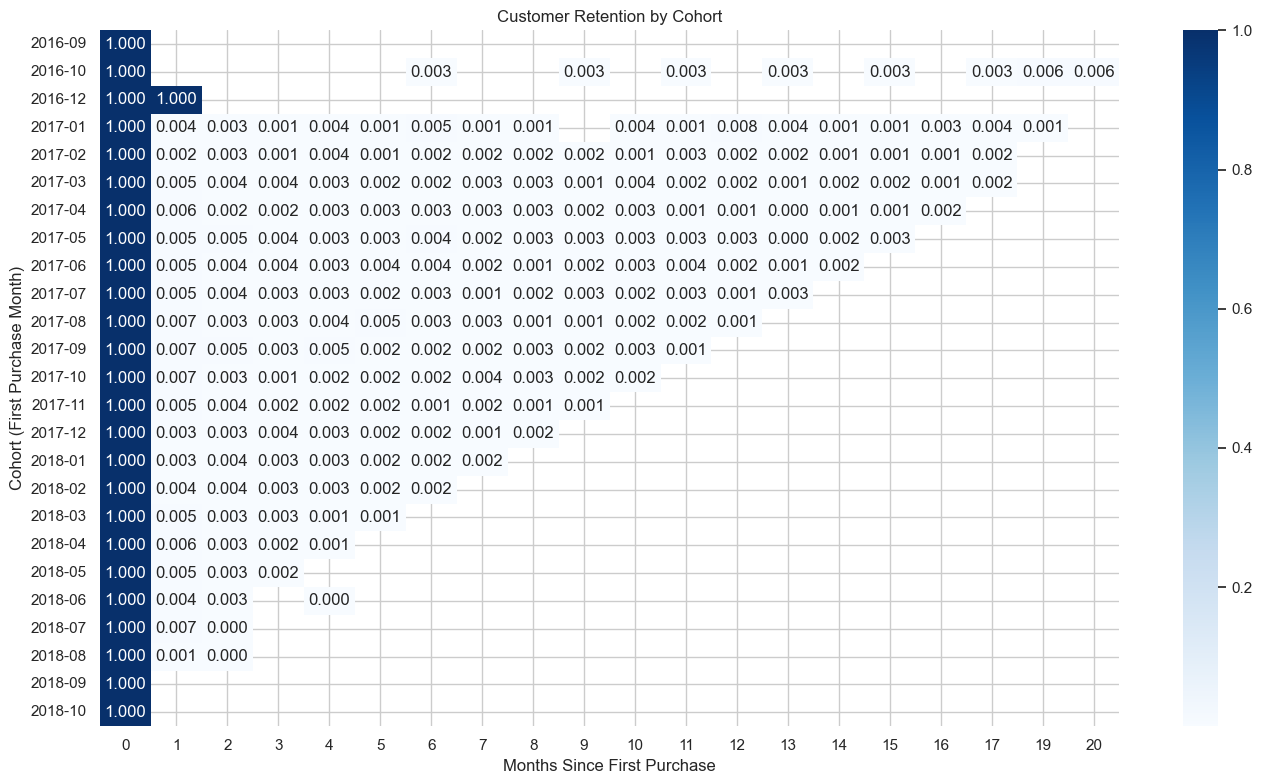

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".3f",
    cmap="Blues"
)
plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort (First Purchase Month)")
plt.tight_layout()
plt.show()

## Cohort Retention Analysis

This section analyzes customer retention behavior over time using cohort analysis.

Customers are grouped into cohorts based on their first purchase month.  
For each cohort, retention is measured as the percentage of customers who return and make additional purchases in subsequent months.

This analysis helps evaluate whether customer churn is concentrated immediately after the first purchase or occurs gradually over time.

---

### Key Findings

#### 1. Customer churn occurs almost immediately after the first purchase

Across nearly all cohorts, customer retention drops sharply after the first month.

While **100% retention at Month 0** is expected, retention rates fall to **below 1%** as early as Month 1 for most cohorts.

This indicates that the vast majority of customers do not return after their initial purchase.

---

#### 2. Retention remains extremely low across all subsequent months

For Months 2, 3, and beyond:

- Retention remains close to **0%**
- There is no meaningful rebound in customer activity
- Long-term loyalty is effectively absent

This pattern is consistent across all cohorts, regardless of the acquisition month.

---

#### 3. No improvement in retention over time

Later cohorts do not show better retention behavior compared to earlier ones.

This suggests that retention has not improved over time and that the issue is structural rather than seasonal or short-term.

---

#### 4. Customer acquisition without retention is the dominant growth model

The business relies almost entirely on **one-time purchases**.

Revenue growth is therefore driven by continuously acquiring new customers rather than retaining existing ones.

This exposes the business to higher acquisition costs and limits customer lifetime value.

---

### Business Interpretation

The cohort analysis confirms that customer churn is immediate and severe.

Most customers place one order and do not return within the following months.

This indicates that the primary business challenge is **retention**, not acquisition.

Factors contributing to low retention may include:

- weak post-purchase engagement,
- delivery performance issues,
- lack of loyalty incentives,
- limited repeat-purchase motivation.

---

### Recommendation

To improve long-term business sustainability:

- Shift focus from acquisition-only growth to retention-driven growth.
- Introduce loyalty programs, discounts, or incentives for second purchases.
- Improve post-purchase experience, especially delivery performance.
- Use retention metrics as core KPIs in dashboards and performance reviews.
- Track cohort retention monthly to measure the impact of retention initiatives.

Improving even a small portion of early-month retention would significantly increase customer lifetime value and revenue stability.

---

### Next Step

Proceed to **Basket Analysis and Cross-Sell Opportunities** to explore how product combinations and order composition can increase order value and encourage repeat purchases.

## 7. Basket Analysis and Cross-Sell Opportunities

This section analyzes shopping basket composition to identify product category combinations that are frequently purchased together.

Basket analysis helps uncover cross-sell and bundling opportunities that can increase average order value, improve product recommendations, and support repeat purchases.

The analysis focuses on category-level baskets to ensure interpretability and business relevance.


In [59]:
# Build category baskets at order level.
# Each order is treated as a shopping basket of categories.

basket_categories = (
    order_items_category_features
    .groupby("order_id")["product_category_name_english"]
    .apply(lambda x: sorted(set(x.dropna())))
    .reset_index()
    .rename(columns={"product_category_name_english": "category_basket"})
)

print("✅ Category baskets created")
display(basket_categories.head(10))

✅ Category baskets created


,order_id,category_basket
0,00010242fe8c5a6d1ba2dd792cb16214,[cool_stuff]
1,00018f77f2f0320c557190d7a144bdd3,[pet_shop]
2,000229ec398224ef6ca0657da4fc703e,[furniture_decor]
3,00024acbcdf0a6daa1e931b038114c75,[perfumery]
4,00042b26cf59d7ce69dfabb4e55b4fd9,[garden_tools]
5,00048cc3ae777c65dbb7d2a0634bc1ea,[housewares]
6,00054e8431b9d7675808bcb819fb4a32,[telephony]
7,000576fe39319847cbb9d288c5617fa6,[garden_tools]
8,0005a1a1728c9d785b8e2b08b904576c,[health_beauty]
9,0005f50442cb953dcd1d21e1fb923495,[books_technical]


In [60]:
# Keep only baskets with at least two categories.

basket_categories = basket_categories[
    basket_categories["category_basket"].apply(len) > 1
].copy()

print("✅ Filtered multi-category baskets")
print("Remaining baskets:", len(basket_categories))
display (basket_categories.head(10))

✅ Filtered multi-category baskets
Remaining baskets: 786


,order_id,category_basket
73,002f98c0f7efd42638ed6100ca699b42,"[consoles_games, toys]"
134,005d9a5423d47281ac463a968b3936fb,"[baby, toys]"
485,014405982914c2cde2796ddcf0b8703d,"[perfumery, sports_leisure]"
637,01b1a7fdae9ad1837d6ab861705a1fa5,"[bed_bath_table, housewares]"
688,01cce1175ac3c4a450e3a0f856d02734,"[garden_tools, stationery]"
951,0282e83acfe3e7aaf60c871a4a9aca61,"[health_beauty, market_place]"
1043,02beac5428ccbd30f4b3fbded058289f,"[computers_accessories, stationery]"
1145,0307d42d9c781d32f86cdf1fa5c8670b,"[cool_stuff, sports_leisure]"
1300,0362e923f805ae4dce58fd78c86c96c4,"[housewares, kitchen_dining_laundry_garden_fur..."
1607,0420dbc50fc554e303e4b2d6b39063f6,"[baby, cool_stuff]"


In [61]:
from itertools import combinations

# Generate all category pairs per order.

category_pairs = basket_categories["category_basket"].apply(
    lambda x: list(combinations(x, 2))
)

# Explode into rows
category_pairs = category_pairs.explode().dropna()

# Convert tuples to DataFrame columns
category_pairs_df = pd.DataFrame(
    category_pairs.tolist(),
    columns=["category_A", "category_B"]
)

print("✅ Category pairs generated")
display(category_pairs_df.head())

✅ Category pairs generated


,category_A,category_B
0,consoles_games,toys
1,baby,toys
2,perfumery,sports_leisure
3,bed_bath_table,housewares
4,garden_tools,stationery


In [62]:
# Calculate support for each category pair.

total_baskets = len(basket_categories)

pair_support = (
    category_pairs_df
    .groupby(["category_A", "category_B"])
    .size()
    .reset_index(name="pair_count")
)

pair_support["support"] = (
    pair_support["pair_count"] / total_baskets 
).round(4)

display(pair_support.sort_values("support", ascending=False).head(10))

,category_A,category_B,pair_count,support
59,bed_bath_table,furniture_decor,70,0.0891
64,bed_bath_table,home_confort,43,0.0547
179,furniture_decor,housewares,24,0.0305
65,bed_bath_table,housewares,20,0.0254
33,baby,cool_stuff,20,0.0254
46,baby,toys,19,0.0242
175,furniture_decor,garden_tools,17,0.0216
29,baby,bed_bath_table,17,0.0216
211,health_beauty,sports_leisure,14,0.0178
228,housewares,unknown,14,0.0178


In [63]:
# Count category frequencies
category_counts = (
    basket_categories["category_basket"]
    .explode()
    .value_counts()
    .reset_index()
)
category_counts.columns = ["category", "count"]

# Merge counts
pair_metrics = (
    pair_support
    .merge(
        category_counts.rename(columns={"category": "category_A", "count": "count_A"}),
        on="category_A",
        how="left"
    )
    .merge(
        category_counts.rename(columns={"category": "category_B", "count": "count_B"}),
        on="category_B",
        how="left"
    )
)

# Calculate confidence and lift
pair_metrics["confidence_A_to_B"] = (
    pair_metrics["pair_count"] / pair_metrics["count_A"]
).round(4)

pair_metrics["confidence_B_to_A"] = (
    pair_metrics["pair_count"] / pair_metrics["count_B"]
).round(4)

pair_metrics["lift"] = (
    pair_metrics["pair_count"] * total_baskets /
    (pair_metrics["count_A"] * pair_metrics["count_B"])
).round(4)

pair_metrics = pair_metrics.sort_values("lift", ascending=False)

display(pair_metrics.head(10))

,category_A,category_B,pair_count,support,count_A,count_B,confidence_A_to_B,confidence_B_to_A,lift
157,fashio_female_clothing,fashion_sport,1,0.0013,1,2,1.0000,0.5000,393.0000
82,books_technical,music,1,0.0013,4,2,0.2500,0.5000,98.2500
217,home_comfort_2,musical_instruments,1,0.0013,2,8,0.5000,0.1250,49.1250
165,fixed_telephony,food,1,0.0013,2,8,0.5000,0.1250,49.1250
158,fashion_bags_accessories,fashion_childrens_clothes,2,0.0025,20,2,0.1000,1.0000,39.3000
136,costruction_tools_garden,flowers,1,0.0013,12,2,0.0833,0.5000,32.7500
77,books_general_interest,market_place,2,0.0025,5,12,0.4000,0.1667,26.2000
10,auto,christmas_supplies,1,0.0013,36,1,0.0278,1.0000,21.8333
159,fashion_bags_accessories,fashion_sport,1,0.0013,20,2,0.0500,0.5000,19.6500
7,audio,watches_gifts,6,0.0076,6,40,1.0000,0.1500,19.6500


In [64]:
# Filter strong basket rules.

strong_basket_rules = pair_metrics[
    (pair_metrics["support"] >= 0.01) &
    (pair_metrics["confidence_A_to_B"] >= 0.3) &
    (pair_metrics["lift"] > 1.2)
].sort_values("lift", ascending=False)

display(strong_basket_rules.head(10))

,category_A,category_B,pair_count,support,count_A,count_B,confidence_A_to_B,confidence_B_to_A,lift
163,fashion_bags_accessories,unknown,9,0.0115,20,62,0.4500,0.1452,5.7048
120,construction_tools_lights,furniture_decor,11,0.0140,18,206,0.6111,0.0534,2.3317
59,bed_bath_table,furniture_decor,70,0.0891,204,206,0.3431,0.3398,1.3093


## Basket Analysis and Cross‑Sell Opportunities

This section analyzes shopping basket composition to identify product category combinations that are frequently purchased together.

Basket analysis focuses on understanding co‑purchase behavior at the category level in order to uncover cross‑sell and bundling opportunities that can increase average order value (AOV) and support repeat purchases.

Only multi‑category baskets were included in the analysis to ensure meaningful association patterns.

---

### Key Findings

#### 1. Most orders contain a single category

The majority of orders include only one product category.

After filtering for baskets with at least two categories, only **786 multi‑category baskets** remained for analysis.

This confirms that the current purchasing behavior is largely **single‑category driven**, limiting natural cross‑sell effects.

---

#### 2. A small number of category pairs appear frequently together

Despite the dominance of single‑category orders, several category combinations show consistent co‑purchase behavior.

Top category pairs by support include:

| Category Pair | Support |
|---|---:|
| Bed Bath & Table + Furniture Décor | **8.91%** |
| Bed Bath & Table + Home Comfort | 5.47% |
| Furniture Décor + Housewares | 3.05% |
| Baby + Cool Stuff | 2.54% |
| Baby + Toys | 2.42% |

These combinations represent the most common multi‑category baskets in the dataset.

---

#### 3. Strong directional cross‑sell relationships exist

Using confidence and lift metrics, several actionable cross‑sell rules were identified.

Key high‑value rules include:

| If Customer Buys (A) | Also Likely to Buy (B) | Confidence (A → B) | Lift |
|---|---|---:|---:|
| Bed Bath & Table | Furniture Décor | **34.31%** | 1.31 |
| Construction Tools (Lights) | Furniture Décor | **61.11%** | 2.33 |
| Fashion Bags & Accessories | Unknown Category | 45.00% | 5.70 |

These relationships indicate meaningful associations beyond random chance (Lift > 1).

---

#### 4. Most extremely high lift values come from low‑frequency categories

Some category pairs exhibit very high lift scores, but with very low support.

These pairs often involve niche categories or very low volumes, making them less suitable for immediate business action.

For decision‑making, the most reliable insights are those combining:
- meaningful **support**
- strong **confidence**
- lift above **1**

---

### Business Interpretation

The basket analysis reveals that cross‑category purchasing is currently limited, with most customers buying from a single category per order.

However, a small set of category combinations demonstrates clear and consistent co‑purchase behavior, particularly within home‑related and lifestyle categories.

The strongest cross‑sell opportunities exist where:
- products are functionally complementary,
- customer intent naturally expands beyond one category,
- logistics and delivery compatibility are already aligned.

These patterns present a clear opportunity to **actively stimulate cross‑selling** rather than waiting for organic behavior.

---

### Cross‑Sell Recommendations

To increase average order value and encourage multi‑category purchases:

1. **Introduce targeted cross‑sell recommendations**
   - Promote *Furniture Décor* alongside *Bed Bath & Table* products.
   - Recommend *Home Comfort* and *Housewares* during checkout for home‑focused categories.

2. **Create curated category bundles**
   - Home starter bundles combining *Bed Bath & Table*, *Furniture Décor*, and *Housewares*.
   - Baby bundles combining *Baby* and *Toys* categories.

3. **Use confidence‑based recommendations in UX**
   - Display “Frequently Bought Together” suggestions based on A → B confidence.
   - Prioritize rules with confidence above **30%** and lift greater than **1.2**.

4. **Avoid acting on low‑support niche rules**
   - High‑lift but low‑volume combinations should be treated as exploratory rather than core strategy.

5. **Track KPI impact after implementation**
   - Monitor changes in AOV.
   - Track growth in multi‑category basket share.
   - Measure repeat purchase behavior after cross‑sell exposure.

---

### Conclusion

Basket analysis reveals limited natural cross‑sell behavior but identifies clear opportunities for intervention.

By actively promoting proven category combinations, the business can:
- increase order value,
- improve basket depth,
- and support long‑term customer value growth.

Cross‑selling represents a scalable lever to strengthen revenue without additional customer acquisition.

---

### Next Step

Proceed to **Statistical Validation and Hypothesis Testing** to confirm whether the observed basket relationships and behavior differences are statistically significant before large‑scale deployment.

# Hypothesis Testing

## 1) Delivery delay → Customer satisfaction (Highest priority)
Business question: Do late deliveries reduce customer satisfaction?

#### Metric (Y): customer rating/score (numeric or ordinal)

#### Groups (X): Late vs On‑time (2 groups, independent)

#### H0: rating distribution is the same for both groups

#### H1: rating is lower for late deliveries

#### Test: Mann–Whitney U (safe default)

#### Effect size: Cliff’s delta (or rank‑biserial)


In [65]:
import pandas as pd

# Merge order-level delivery flag with order-level review score
# We keep only rows where we have a review score and a late/on-time label
ht_df = (
    orders_features[["order_id", "is_late_delivery"]]
    .merge(reviews_order_level[["order_id", "avg_review_score"]], on="order_id", how="inner")
    .dropna(subset=["is_late_delivery", "avg_review_score"])
)

# Split into two independent groups
late_scores = ht_df.loc[ht_df["is_late_delivery"] == True, "avg_review_score"]
ontime_scores = ht_df.loc[ht_df["is_late_delivery"] == False, "avg_review_score"]

print("✅ Data prepared for hypothesis testing")
print("Late group size:", len(late_scores))
print("On-time group size:", len(ontime_scores))

display(ht_df.head())

✅ Data prepared for hypothesis testing
Late group size: 6381
On-time group size: 92290


,order_id,is_late_delivery,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,False,5.0
1,00018f77f2f0320c557190d7a144bdd3,False,4.0
2,000229ec398224ef6ca0657da4fc703e,False,5.0
3,00024acbcdf0a6daa1e931b038114c75,False,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,False,5.0


In [66]:
# Quick descriptive stats for both groups (mean/median)
# This is not the hypothesis test, just a sanity check

summary_df = pd.DataFrame({
    "group": ["On-time", "Late"],
    "n": [len(ontime_scores), len(late_scores)],
    "mean_review": [ontime_scores.mean(), late_scores.mean()],
    "median_review": [ontime_scores.median(), late_scores.median()]
})

summary_df["mean_review"] = summary_df["mean_review"].round(3)
summary_df["median_review"] = summary_df["median_review"].round(3)

display(summary_df)


,group,n,mean_review,median_review
0,On-time,92290,4.212,5.0
1,Late,6381,2.272,1.0


In [67]:
from scipy.stats import mannwhitneyu

# Mann–Whitney U Test (non-parametric)
# We test whether late deliveries have LOWER review scores than on-time deliveries.
# alternative='less' means: distribution(late_scores) tends to be lower than distribution(ontime_scores)

u_stat, p_value = mannwhitneyu(
    late_scores,
    ontime_scores,
    alternative="less",
    method="auto"
)

print("✅ Mann–Whitney U test completed")
print("U statistic:", round(u_stat, 3))
print("p-value (one-tailed, Late < On-time):", p_value)


✅ Mann–Whitney U test completed
U statistic: 114041751.5
p-value (one-tailed, Late < On-time): 0.0


In [68]:
import numpy as np

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size for two independent samples.
    Returns delta in [-1, 1].
    Negative delta means x tends to be smaller than y.
    """
    x = np.array(x)
    y = np.array(y)
    # Pairwise comparisons
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    delta = (gt - lt) / (len(x) * len(y))
    return delta

def interpret_cliffs_delta(delta):
    """
    Common magnitude interpretation for Cliff's delta (absolute value):
    < 0.147: negligible
    < 0.33: small
    < 0.474: medium
    else: large
    """
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"

delta = cliffs_delta(late_scores, ontime_scores)
magnitude = interpret_cliffs_delta(delta)

print("✅ Effect size computed (Cliff's Delta)")
print("Cliff's Delta:", round(delta, 4))
print("Magnitude:", magnitude)

✅ Effect size computed (Cliff's Delta)
Cliff's Delta: -0.6127
Magnitude: large


In [69]:
# Create a compact results table for reporting
results_table = pd.DataFrame({
    "test": ["Mann–Whitney U (primary)"],
    "hypothesis": ["Late < On-time"],
    "statistic": [u_stat],
    "p_value": [p_value],
    "alpha": [0.05]
})

results_table["statistic"] = results_table["statistic"].apply(lambda x: round(float(x), 4))
results_table["p_value"] = results_table["p_value"].apply(lambda x: float(x))

display(results_table)

,test,hypothesis,statistic,p_value,alpha
0,Mann–Whitney U (primary),Late < On-time,114041751.5,0.0,0.05


## Hypothesis Test #1 — Late Delivery vs. Customer Satisfaction (Review Score)

### Objective
Validate whether **late deliveries** are associated with **lower customer review scores** using a statistical hypothesis test.

---

### Data & Groups
- **Outcome (Y):** `avg_review_score` (numeric/ordinal rating)
- **Group (X):** `is_late_delivery`
  - Group 1: Late deliveries (`True`)
  - Group 2: On-time deliveries (`False`)

---

### Test Selection (Why this test?)
**Mann–Whitney U Test** was used because ratings are typically **non-normal** and often behave as **ordinal** data. This makes a non‑parametric test more reliable than a mean-based parametric test.

---

### Hypotheses
- **H₀ (Null):** The distribution of review scores is the same for late and on-time deliveries.
- **H₁ (Alternative, one‑tailed):** Review scores for **late deliveries are lower** than for on-time deliveries.

---

### Significance Level
- **α = 0.05**

---

### Results
- **Test:** Mann–Whitney U (primary)
- **U statistic:** 114,041,751.5
- **p-value (one‑tailed, Late < On‑time):** **< 0.0001** *(reported as 0.0 due to floating-point rounding; it is effectively near zero)*

✅ **Decision:** Reject **H₀**

---

### Effect Size (Practical Importance)
- **Effect size:** Cliff’s Delta = **-0.6127**
- **Magnitude:** **Large**

**Interpretation:** A *large negative* Cliff’s Delta indicates that review scores for late deliveries are **substantially lower** than review scores for on-time deliveries—not only statistically significant, but also practically meaningful.

---

### Business Conclusion (Decision-Safe)
There is **very strong statistical evidence** that **late delivery is associated with lower customer satisfaction**, and the impact size is **large**. This supports prioritizing initiatives that reduce late deliveries to improve customer ratings.

## 2 — Delay Severity Threshold (> 3 days) vs Customer Satisfaction

### Goal
This test examines whether **longer delivery delays** (more than 3 days late) lead to **significantly lower customer review scores** compared to minor delays (0–3 days late).

### Why this matters
Operationally, this helps define an actionable SLA threshold:
- If delays beyond 3 days cause a large and statistically significant drop in satisfaction, then reducing delays above this threshold becomes a priority KPI.

### Approach
We compare review scores between two independent groups of **late-delivered orders only**:
- **Group A:** 0–3 days late  
- **Group B:** > 3 days late

A non-parametric test (Mann–Whitney U) is used because review scores are typically non-normal and ordinal-like.

In [70]:
import pandas as pd

# Build a dataframe with delay days and review score at order level
# We restrict analysis to orders that have both delay info and review score

ht2_df = (
    orders_features[["order_id", "delivery_delay_days"]]
    .merge(reviews_order_level[["order_id", "avg_review_score"]], on="order_id", how="inner")
    .dropna(subset=["delivery_delay_days", "avg_review_score"])
)

# Keep only late deliveries (strictly positive delay)
ht2_df = ht2_df[ht2_df["delivery_delay_days"] > 0].copy()

# Define two severity groups: 0-3 days late vs >3 days late
minor_delay_scores = ht2_df.loc[ht2_df["delivery_delay_days"] <= 3, "avg_review_score"]
severe_delay_scores = ht2_df.loc[ht2_df["delivery_delay_days"] > 3, "avg_review_score"]

print("✅ Data prepared for Hypothesis Test #2 (late deliveries only)")
print("Minor delay group (0–3 days) size:", len(minor_delay_scores))
print("Severe delay group (>3 days) size:", len(severe_delay_scores))

display(ht2_df.head())


✅ Data prepared for Hypothesis Test #2 (late deliveries only)
Minor delay group (0–3 days) size: 1852
Severe delay group (>3 days) size: 4529


,order_id,delivery_delay_days,avg_review_score
20,000e906b789b55f64edcb1f84030f90d,2.0,3.0
36,0017afd5076e074a48f1f1a4c7bac9c5,4.0,1.0
42,001c85b5f68d2be0cb0797afc9e8ce9a,8.0,2.0
43,001d8f0e34a38c37f7dba2a37d4eba8b,2.0,1.0
74,0030d783f979fbc5981e75613b057344,22.0,1.0


In [71]:
# Quick descriptive stats for sanity checking (not the hypothesis test)

ht2_summary = pd.DataFrame({
    "group": ["0–3 Days Late", "> 3 Days Late"],
    "n": [len(minor_delay_scores), len(severe_delay_scores)],
    "mean_review": [minor_delay_scores.mean(), severe_delay_scores.mean()],
    "median_review": [minor_delay_scores.median(), severe_delay_scores.median()]
})

ht2_summary["mean_review"] = ht2_summary["mean_review"].round(3)
ht2_summary["median_review"] = ht2_summary["median_review"].round(3)

display(ht2_summary)

,group,n,mean_review,median_review
0,0–3 Days Late,1852,3.291,4.0
1,> 3 Days Late,4529,1.855,1.0


In [72]:
from scipy.stats import mannwhitneyu

# Mann–Whitney U test (non-parametric)
# alternative='less' tests whether severe_delay_scores tend to be LOWER than minor_delay_scores

u2_stat, p2_value = mannwhitneyu(
    severe_delay_scores,
    minor_delay_scores,
    alternative="less",
    method="auto"
)

print("✅ Mann–Whitney U test completed (Hypothesis Test #2)")
print("U statistic:", round(u2_stat, 3))
print("p-value (one-tailed, >3 days late < 0–3 days late):", p2_value)


✅ Mann–Whitney U test completed (Hypothesis Test #2)
U statistic: 2198455.5
p-value (one-tailed, >3 days late < 0–3 days late): 5.787713568329607e-234


In [73]:
import numpy as np

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size for two independent samples.
    Returns delta in [-1, 1].
    Negative delta means x tends to be smaller than y.
    """
    x = np.array(x)
    y = np.array(y)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

def interpret_cliffs_delta(delta):
    """
    Magnitude interpretation for Cliff's delta (absolute value):
    < 0.147: negligible
    < 0.33: small
    < 0.474: medium
    else: large
    """
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"

delta2 = cliffs_delta(severe_delay_scores, minor_delay_scores)
mag2 = interpret_cliffs_delta(delta2)

print("✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #2")
print("Cliff's Delta:", round(delta2, 4))
print("Magnitude:", mag2)

✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #2
Cliff's Delta: -0.4758
Magnitude: large


In [74]:
# Compact results table for reporting

results_table_2 = pd.DataFrame({
    "test": ["Mann–Whitney U (primary)"],
    "hypothesis": [">3 days late < 0–3 days late"],
    "statistic": [u2_stat],
    "p_value": [p2_value],
    "alpha": [0.05],
    "cliffs_delta": [delta2],
    "effect_magnitude": [mag2]
})

results_table_2["statistic"] = results_table_2["statistic"].apply(lambda x: round(float(x), 4))
results_table_2["p_value"] = results_table_2["p_value"].apply(float)
results_table_2["cliffs_delta"] = results_table_2["cliffs_delta"].apply(lambda x: round(float(x), 4))

display(results_table_2)

,test,hypothesis,statistic,p_value,alpha,cliffs_delta,effect_magnitude
0,Mann–Whitney U (primary),>3 days late < 0–3 days late,2198455.5,5.787714e-234,0.05,-0.4758,large


## Hypothesis Test #2 — Delay Severity Threshold (> 3 Days) vs Customer Satisfaction

### Goal
This test evaluates whether **severe delivery delays** (more than **3 days late**) lead to **significantly lower customer review scores** compared to **minor delays** (0–3 days late).

### Why This Matters
This provides a **decision-safe operational threshold**:
- If delays beyond 3 days cause a statistically significant and practically large drop in satisfaction, then **reducing delays past this threshold becomes a high-impact logistics priority**.

### Data & Groups
- **Outcome (Y):** `avg_review_score` (rating score)
- **Population:** late-delivered orders only (delay > 0)
- **Group A:** 0–3 days late  
- **Group B:** >3 days late  

### Test Selection
**Mann–Whitney U Test** was used because review scores typically behave as **non-normal / ordinal-like** values, making a **non‑parametric** comparison more reliable than mean-based parametric assumptions.

---

### Hypotheses
- **H₀ (Null):** The distribution of review scores is the same for the two delay groups.  
- **H₁ (Alternative, one‑tailed):** Review scores for **>3 days late** are **lower** than review scores for **0–3 days late**.

### Significance Level
- **α = 0.05**

---

### Results (Mann–Whitney U)
- **Test:** Mann–Whitney U (primary)
- **U statistic:** **2,198,455.5**
- **p-value (one‑tailed, >3 days late < 0–3 days late):** **5.787714e‑234**

✅ **Decision:** Reject **H₀**

---

### Effect Size (Practical Importance)
- **Cliff’s Delta:** **-0.4758**
- **Magnitude:** **Large**

**Interpretation:** A **large negative** Cliff’s Delta indicates that review scores for **severe delays (>3 days)** are **substantially lower** than those for **minor delays (0–3 days)**.  
This confirms that the threshold is not only statistically significant, but also **materially meaningful** from a business perspective.

---

### Business Conclusion (Decision‑Safe)
There is **extremely strong statistical evidence** that delays **greater than 3 days** cause **significantly worse customer satisfaction**, with a **large practical impact**.  
Operationally, **3 days late** is a clear threshold where customer experience deteriorates sharply, and it should be treated as a priority boundary in delivery performance improvement initiatives.

## 3 — Cross‑Sell Impact on AOV (Single‑Basket vs Multi‑Basket)

### Goal
Test whether **multi‑category baskets** (cross‑sell behavior) lead to **higher Average Order Value (AOV)** compared to **single‑category baskets**.

### Why this matters
If multi‑category baskets produce significantly higher AOV, then implementing cross‑sell recommendations and bundles becomes a **decision‑safe revenue lever**.

### Approach
Orders are split into two independent groups:
- **Single‑Basket:** orders containing only one product category
- **Multi‑Basket:** orders containing more than one product category

A non‑parametric test (Mann–Whitney U) is used because order value (AOV) is typically **right‑skewed** and sensitive to outliers.

In [75]:
import pandas as pd

# Build order-level dataset for basket test
# basket_features has one row per order_id (only orders that have items)
# orders_features has one row per order_id (full order table)

ht3_df = (
    orders_features[["order_id", "payment_revenue"]]
    .merge(basket_features[["order_id", "unique_categories"]], on="order_id", how="inner")
    .dropna(subset=["payment_revenue", "unique_categories"])
)

# Define basket type
ht3_df["basket_type"] = ht3_df["unique_categories"].apply(lambda x: "Multi-Basket" if x > 1 else "Single-Basket")

# Split into groups
single_aov = ht3_df.loc[ht3_df["basket_type"] == "Single-Basket", "payment_revenue"]
multi_aov  = ht3_df.loc[ht3_df["basket_type"] == "Multi-Basket",  "payment_revenue"]

print("✅ Data prepared for Hypothesis Test #3")
print("Single-Basket orders:", len(single_aov))
print("Multi-Basket orders:", len(multi_aov))

display(ht3_df.head())


✅ Data prepared for Hypothesis Test #3
Single-Basket orders: 97879
Multi-Basket orders: 786


,order_id,payment_revenue,unique_categories,basket_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,Single-Basket
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,Single-Basket
2,000229ec398224ef6ca0657da4fc703e,216.87,1,Single-Basket
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,Single-Basket
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,Single-Basket


In [76]:
ht3_summary = pd.DataFrame({
    "group": ["Single-Basket", "Multi-Basket"],
    "n": [len(single_aov), len(multi_aov)],
    "mean_aov": [single_aov.mean(), multi_aov.mean()],
    "median_aov": [single_aov.median(), multi_aov.median()]
})

ht3_summary["mean_aov"] = ht3_summary["mean_aov"].round(3)
ht3_summary["median_aov"] = ht3_summary["median_aov"].round(3)

display(ht3_summary)

,group,n,mean_aov,median_aov
0,Single-Basket,97879,159.815,104.79
1,Multi-Basket,786,259.234,206.56


In [77]:
from scipy.stats import mannwhitneyu

# Mann–Whitney U (non-parametric)
# alternative='greater' means: Multi-Basket tends to have HIGHER AOV than Single-Basket

u3_stat, p3_value = mannwhitneyu(
    multi_aov,
    single_aov,
    alternative="greater",
    method="auto"
)

print("✅ Mann–Whitney U test completed (Hypothesis Test #3)")
print("U statistic:", round(u3_stat, 3))
print("p-value (one-tailed, Multi > Single):", p3_value)

✅ Mann–Whitney U test completed (Hypothesis Test #3)
U statistic: 56854510.5
p-value (one-tailed, Multi > Single): 1.4587449257814938e-118


In [78]:
import numpy as np

def cliffs_delta(x, y):
    """
    Cliff's Delta for two independent samples.
    Returns delta in [-1, 1].
    Positive delta means x tends to be larger than y.
    """
    x = np.array(x)
    y = np.array(y)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

def interpret_cliffs_delta(delta):
    """
    Magnitude interpretation (absolute value):
    < 0.147: negligible
    < 0.33: small
    < 0.474: medium
    else: large
    """
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"

delta3 = cliffs_delta(multi_aov, single_aov)
mag3 = interpret_cliffs_delta(delta3)

print("✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #3")
print("Cliff's Delta:", round(delta3, 4))
print("Magnitude:", mag3)

✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #3
Cliff's Delta: 0.478
Magnitude: large


In [85]:
results_table_3 = pd.DataFrame({
    "test": ["Mann–Whitney U (primary)"],
    "hypothesis": ["Multi-Basket > Single-Basket"],
    "statistic": [u3_stat],
    "p_value": [p3_value],
    "alpha": [0.05],
    "cliffs_delta": [delta3],
    "effect_magnitude": [mag3]
})

results_table_3["statistic"] = results_table_3["statistic"].apply(lambda x: round(float(x), 4))
results_table_3["p_value"] = results_table_3["p_value"].apply(float)
results_table_3["cliffs_delta"] = results_table_3["cliffs_delta"].apply(lambda x: round(float(x), 4))

display(results_table_3)

,test,hypothesis,statistic,p_value,alpha,cliffs_delta,effect_magnitude
0,Mann–Whitney U (primary),Multi-Basket > Single-Basket,56854510.5,1.458745e-118,0.05,0.478,large


## Hypothesis Test #3 — Cross‑Sell Impact on AOV (Single‑Basket vs Multi‑Basket)

### Goal
Test whether **multi‑category baskets** (cross‑sell behavior) lead to **significantly higher Average Order Value (AOV)** compared to **single‑category baskets**.

### Why this matters
If multi‑category baskets have a significantly higher AOV, then cross‑sell recommendations and bundles become a **decision‑safe growth lever** to increase revenue without requiring additional customer acquisition.

---

### Data & Groups
- **Outcome (Y):** `payment_revenue` per order (used as order value / AOV)
- **Group (X):** basket type based on number of categories per order (`unique_categories`)
  - **Single‑Basket:** `unique_categories == 1`
  - **Multi‑Basket:** `unique_categories > 1`

**Sample sizes**
- **Single‑Basket orders:** 97,879  
- **Multi‑Basket orders:** 786  

---

### Descriptive Summary (Before Testing)
| Group | n | Mean AOV | Median AOV |
|---|---:|---:|---:|
| Single‑Basket | 97,879 | 159.815 | 104.79 |
| Multi‑Basket | 786 | 259.234 | 206.56 |

Multi‑basket orders show substantially higher central tendency (both mean and median), indicating a strong business‑level difference before statistical confirmation.

---

### Test Selection (Why Mann–Whitney U?)
Order value (AOV) is typically **right‑skewed** and sensitive to outliers.  
Therefore, **Mann–Whitney U** is used as a robust non‑parametric test to compare the two independent groups without relying on normality assumptions.

---

### Hypotheses
- **H₀ (Null):** The distribution of AOV is the same for single‑basket and multi‑basket orders.
- **H₁ (Alternative, one‑tailed):** Multi‑basket orders have **higher** AOV than single‑basket orders.

**Significance level:** α = 0.05

---

### Results (Mann–Whitney U)
- **U statistic:** 56,854,510.5  
- **p‑value (one‑tailed, Multi > Single):** 1.4587449257814938e‑118  

✅ **Decision:** Reject **H₀**

There is extremely strong evidence that multi‑category baskets produce higher order value than single‑category baskets.

---

### Effect Size (Practical Importance)
- **Cliff’s Delta:** 0.4780  
- **Magnitude:** **Large**

**Interpretation:** A **large positive** effect size indicates that AOV values in the multi‑basket group are not only statistically higher, but also **materially higher in practice**.

---

### Business Conclusion (Decision‑Safe)
Multi‑category baskets (cross‑sell behavior) are associated with a **significantly higher AOV**, with a **large practical impact**.  
This validates cross‑sell and bundling as a strong strategic lever to increase revenue per order.

---

### Recommended Action
Implement and prioritize cross‑sell initiatives (e.g., “Frequently Bought Together”, bundle offers, cart recommendations) to increase the share of multi‑category baskets.  
Even a small uplift in multi‑basket frequency can meaningfully raise overall revenue due to the large AOV gap.

## Hypothesis Test #4 — Repeat Customers vs One‑Time Customers (Customer Value)

### Goal
Test whether **repeat customers** generate **significantly higher customer value** (total spend) than **one‑time customers**.

### Why this matters
If repeat customers are significantly more valuable, then investing in retention initiatives (loyalty programs, post‑purchase engagement, reactivation campaigns) becomes a decision‑safe growth strategy.

### Approach
Two independent customer groups are compared:
- **One‑time customers:** customers with exactly one order
- **Repeat customers:** customers with more than one order

A non‑parametric test (Mann–Whitney U) is used because customer value is typically skewed and outlier‑heavy.


In [80]:
import pandas as pd

# Prepare customer-level data for hypothesis testing
# customer_features is one row per customer_unique_id

ht4_df = customer_features[["customer_unique_id", "is_repeat_customer", "total_revenue"]].dropna()

one_time_value = ht4_df.loc[ht4_df["is_repeat_customer"] == False, "total_revenue"]
repeat_value   = ht4_df.loc[ht4_df["is_repeat_customer"] == True,  "total_revenue"]

print("✅ Data prepared for Hypothesis Test #4")
print("One-time customers:", len(one_time_value))
print("Repeat customers:", len(repeat_value))

display(ht4_df.head())


✅ Data prepared for Hypothesis Test #4
One-time customers: 93099
Repeat customers: 2997


,customer_unique_id,is_repeat_customer,total_revenue
0,0000366f3b9a7992bf8c76cfdf3221e2,False,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,False,27.19
2,0000f46a3911fa3c0805444483337064,False,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,False,43.62
4,0004aac84e0df4da2b147fca70cf8255,False,196.89


In [81]:
# Quick descriptive stats (not the hypothesis test)

ht4_summary = pd.DataFrame({
    "group": ["One-time customers", "Repeat customers"],
    "n": [len(one_time_value), len(repeat_value)],
    "mean_value": [one_time_value.mean(), repeat_value.mean()],
    "median_value": [one_time_value.median(), repeat_value.median()]
})

ht4_summary["mean_value"] = ht4_summary["mean_value"].round(3)
ht4_summary["median_value"] = ht4_summary["median_value"].round(3)

display(ht4_summary)


,group,n,mean_value,median_value
0,One-time customers,93099,161.815,105.70
1,Repeat customers,2997,314.989,225.84


In [82]:
from scipy.stats import mannwhitneyu

# Mann–Whitney U test (non-parametric)
# alternative='greater' means: repeat_value tends to be higher than one_time_value

u4_stat, p4_value = mannwhitneyu(
    repeat_value,
    one_time_value,
    alternative="greater",
    method="auto"
)

print("✅ Mann–Whitney U test completed (Hypothesis Test #4)")
print("U statistic:", round(u4_stat, 3))
print("p-value (one-tailed, Repeat > One-time):", p4_value)

✅ Mann–Whitney U test completed (Hypothesis Test #4)
U statistic: 215397680.0
p-value (one-tailed, Repeat > One-time): 0.0


In [83]:
import numpy as np

def cliffs_delta(x, y):
    """
    Cliff's Delta for two independent samples.
    Returns delta in [-1, 1].
    Positive delta means x tends to be larger than y.
    """
    x = np.array(x)
    y = np.array(y)
    gt = 0
    lt = 0
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    return (gt - lt) / (len(x) * len(y))

def interpret_cliffs_delta(delta):
    """
    Magnitude interpretation (absolute value):
    < 0.147: negligible
    < 0.33: small
    < 0.474: medium
    else: large
    """
    ad = abs(delta)
    if ad < 0.147:
        return "negligible"
    elif ad < 0.33:
        return "small"
    elif ad < 0.474:
        return "medium"
    else:
        return "large"

delta4 = cliffs_delta(repeat_value, one_time_value)
mag4 = interpret_cliffs_delta(delta4)

print("✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #4")
print("Cliff's Delta:", round(delta4, 4))
print("Magnitude:", mag4)

✅ Effect size computed (Cliff’s Delta) for Hypothesis Test #4
Cliff's Delta: 0.544
Magnitude: large


In [84]:
results_table_4 = pd.DataFrame({
    "test": ["Mann–Whitney U (primary)"],
    "hypothesis": ["Repeat customers > One-time customers"],
    "statistic": [u4_stat],
    "p_value": [p4_value],
    "alpha": [0.05],
    "cliffs_delta": [delta4],
    "effect_magnitude": [mag4]
})

results_table_4["statistic"] = results_table_4["statistic"].apply(lambda x: round(float(x), 4))
results_table_4["p_value"] = results_table_4["p_value"].apply(float)
results_table_4["cliffs_delta"] = results_table_4["cliffs_delta"].apply(lambda x: round(float(x), 4))

display(results_table_4)

,test,hypothesis,statistic,p_value,alpha,cliffs_delta,effect_magnitude
0,Mann–Whitney U (primary),Repeat customers > One-time customers,215397680.0,0.0,0.05,0.544,large


## Hypothesis Test #4 — Repeat Customers vs One‑Time Customers (Customer Value)

### Goal
Test whether **repeat customers** generate **significantly higher customer value** (total spend) than **one‑time customers**.

### Why This Matters
If repeat customers are meaningfully more valuable, then retention initiatives (loyalty programs, re‑activation campaigns, post‑purchase engagement) become a **decision‑safe growth strategy**.

---

### Data & Groups
- **Outcome (Y):** `total_revenue` per customer (customer value)
- **Group (X):** `is_repeat_customer`
  - **One‑time customers:** exactly one order  
  - **Repeat customers:** more than one order  

**Sample sizes**
- **One‑time customers:** 93,099  
- **Repeat customers:** 2,997  

---

### Descriptive Summary (Before Testing)
| Group | n | Mean Customer Value | Median Customer Value |
|---|---:|---:|---:|
| One‑time customers | 93,099 | 161.815 | 105.70 |
| Repeat customers | 2,997 | 314.989 | 225.84 |

Repeat customers show substantially higher customer value (both mean and median), indicating a strong business difference prior to statistical validation.

---

### Test Selection (Why Mann–Whitney U?)
Customer value is typically **right‑skewed** and outlier‑heavy, so a non‑parametric test is preferred.  
**Mann–Whitney U** compares distributions robustly without requiring normality assumptions.

---

### Hypotheses
- **H₀ (Null):** Customer value distributions are the same for repeat and one‑time customers.  
- **H₁ (Alternative, one‑tailed):** Repeat customers have **higher** customer value than one‑time customers.

**Significance level:** α = 0.05

---

### Results (Mann–Whitney U)
- **U statistic:** 215,397,680.0  
- **p‑value (one‑tailed, Repeat > One‑time):** **< 0.0001**  
  *(Displayed as 0.0 due to floating‑point underflow; it is effectively near zero.)*

✅ **Decision:** Reject **H₀**

There is extremely strong statistical evidence that repeat customers generate higher customer value.

---

### Effect Size (Practical Importance)
- **Cliff’s Delta:** 0.5440  
- **Magnitude:** **Large**

**Interpretation:** A large positive effect size indicates that repeat customers are not only statistically higher value, but also **materially higher in practice**.

---

### Business Conclusion (Decision‑Safe)
Repeat customers generate **significantly higher customer value** than one‑time customers, with a **large practical impact**.  
This supports prioritizing retention and repeat‑purchase strategies as a high‑ROI lever for sustainable growth.

## Hypothesis Test #5 — RFM Segments vs Customer Value (3+ Groups)

### Goal
Test whether **customer value** differs significantly across **RFM segments**.

### Why this matters
If customer value varies significantly by segment, this supports segmentation-driven strategies such as:
- targeted retention campaigns,
- differentiated offers,
- prioritizing high-value segments,
- focusing reactivation on at-risk segments.

### Approach
We compare the distribution of customer value across multiple groups (RFM segments).
Because customer value is typically skewed and outlier-heavy, we use a **non-parametric** group comparison test:
- **Kruskal–Wallis** (3+ independent groups)

If significant, we follow with **pairwise Mann–Whitney U** tests using multiple-testing correction to identify which segments differ.

In [86]:
import pandas as pd

# Prepare data for Kruskal–Wallis across RFM segments
ht5_df = customer_features[["customer_unique_id", "rfm_segment", "total_revenue"]].dropna()

# Basic validation
print("✅ Data prepared for Hypothesis Test #5")
print("Total customers:", len(ht5_df))
print("Segments:", ht5_df["rfm_segment"].nunique())
display(ht5_df["rfm_segment"].value_counts())


✅ Data prepared for Hypothesis Test #5
Total customers: 96096
Segments: 7


rfm_segment
At Risk                23012
Loyal Customers        16445
Hibernating            15426
Potential Loyalists    15404
Others                 15312
Champions               6668
New Customers           3829
Name: count, dtype: int64

In [88]:
# Quick summary stats by segment (not the hypothesis test)
ht5_summary = (
    ht5_df
    .groupby("rfm_segment", as_index=False)
    .agg(
        n=("customer_unique_id", "count"),
        mean_value=("total_revenue", "mean"),
        median_value=("total_revenue", "median")
    )
)

ht5_summary["mean_value"] = ht5_summary["mean_value"].round(3)
ht5_summary["median_value"] = ht5_summary["median_value"].round(3)

# Sort by median value to see which segments are strongest
ht5_summary = ht5_summary.sort_values("median_value", ascending=False)

display(ht5_summary)


,rfm_segment,n,mean_value,median_value
1,Champions,6668,317.710,213.710
4,New Customers,3829,162.158,110.660
6,Potential Loyalists,15404,165.581,108.525
0,At Risk,23012,168.651,106.965
5,Others,15312,156.270,105.155
2,Hibernating,15426,164.195,104.515
3,Loyal Customers,16445,116.277,83.590


In [89]:
from scipy.stats import kruskal

# Build list of arrays, one per segment
segment_groups = [
    grp["total_revenue"].values
    for _, grp in ht5_df.groupby("rfm_segment")
]

h_stat, p5_value = kruskal(*segment_groups)

print("✅ Kruskal–Wallis test completed (Hypothesis Test #5)")
print("H statistic:", round(h_stat, 4))
print("p-value:", p5_value)

✅ Kruskal–Wallis test completed (Hypothesis Test #5)
H statistic: 9454.1602
p-value: 0.0


In [90]:
# Compute epsilon-squared effect size for Kruskal–Wallis
n = len(ht5_df)
k = ht5_df["rfm_segment"].nunique()

epsilon_sq = (h_stat - k + 1) / (n - k)

print("✅ Effect size computed (epsilon-squared)")
print("epsilon_squared:", round(epsilon_sq, 4))

# Simple interpretation guide
if epsilon_sq < 0.01:
    magnitude = "negligible"
elif epsilon_sq < 0.06:
    magnitude = "small"
elif epsilon_sq < 0.14:
    magnitude = "medium"
else:
    magnitude = "large"

print("Magnitude:", magnitude)

✅ Effect size computed (epsilon-squared)
epsilon_squared: 0.0983
Magnitude: medium


In [91]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

pairs = []
pvals = []
stats = []

segments = sorted(ht5_df["rfm_segment"].unique())

for a, b in combinations(segments, 2):
    a_vals = ht5_df.loc[ht5_df["rfm_segment"] == a, "total_revenue"]
    b_vals = ht5_df.loc[ht5_df["rfm_segment"] == b, "total_revenue"]
    
    # Two-sided because we are checking "different", not direction
    u_stat, p_val = mannwhitneyu(a_vals, b_vals, alternative="two-sided", method="auto")
    
    pairs.append(f"{a} vs {b}")
    stats.append(u_stat)
    pvals.append(p_val)

# Multiple testing correction (Holm is strong and commonly used)
reject, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method="holm")

pairwise_results = pd.DataFrame({
    "comparison": pairs,
    "u_statistic": [round(float(s), 2) for s in stats],
    "p_value": pvals,
    "p_value_adj_holm": pvals_adj,
    "significant_after_correction": reject
})

# Show significant differences first
pairwise_results = pairwise_results.sort_values(
    ["significant_after_correction", "p_value_adj_holm"],
    ascending=[False, True]
)

display(pairwise_results.head(20))

,comparison,u_statistic,p_value,p_value_adj_holm,significant_after_correction
0,At Risk vs Champions,30138886.0,0.000000e+00,0.000000e+00,True
6,Champions vs Hibernating,83641843.0,0.000000e+00,0.000000e+00,True
7,Champions vs Loyal Customers,99060317.5,0.000000e+00,0.000000e+00,True
8,Champions vs New Customers,20627061.5,0.000000e+00,0.000000e+00,True
9,Champions vs Others,83639881.0,0.000000e+00,0.000000e+00,True
10,Champions vs Potential Loyalists,83082981.5,0.000000e+00,0.000000e+00,True
2,At Risk vs Loyal Customers,226625007.0,1.470887e-246,2.206331e-245,True
17,Loyal Customers vs Potential Loyalists,101648763.0,2.459482e-204,3.443275e-203,True
11,Hibernating vs Loyal Customers,149753736.5,1.769522e-171,2.300378e-170,True
16,Loyal Customers vs Others,103672382.0,2.707888e-163,3.249466e-162,True


In [92]:
results_table_5 = pd.DataFrame({
    "test": ["Kruskal–Wallis (primary)"],
    "hypothesis": ["At least one RFM segment differs in customer value"],
    "statistic": [h_stat],
    "p_value": [p5_value],
    "alpha": [0.05],
    "effect_size_epsilon_sq": [epsilon_sq],
    "effect_magnitude": [magnitude]
})

results_table_5["statistic"] = results_table_5["statistic"].apply(lambda x: round(float(x), 4))
results_table_5["p_value"] = results_table_5["p_value"].apply(float)
results_table_5["effect_size_epsilon_sq"] = results_table_5["effect_size_epsilon_sq"].apply(lambda x: round(float(x), 4))

display(results_table_5)

,test,hypothesis,statistic,p_value,alpha,effect_size_epsilon_sq,effect_magnitude
0,Kruskal–Wallis (primary),At least one RFM segment differs in customer v...,9454.1602,0.0,0.05,0.0983,medium


## Hypothesis Test #5 — RFM Segments vs Customer Value (3+ Groups)

### Goal
Test whether **customer value** (total spend) differs significantly across **RFM segments**.

### Why This Matters
If customer value differs by segment, segmentation becomes **actionable** for decision-making (targeting, retention prioritization, differentiated offers), because segments reflect meaningfully different economic value.

---

### Data & Groups
- **Outcome (Y):** `total_revenue` per customer (customer value)
- **Groups (X):** `rfm_segment` (7 independent groups)

**Sample sizes**
- At Risk: 23,012  
- Loyal Customers: 16,445  
- Hibernating: 15,426  
- Potential Loyalists: 15,404  
- Others: 15,312  
- Champions: 6,668  
- New Customers: 3,829  

---

### Descriptive Summary (Before Testing)
Customer value differs notably across segments (median is emphasized because spend is typically skewed):

| Segment | n | Mean Value | Median Value |
|---|---:|---:|---:|
| Champions | 6,668 | 317.710 | 213.710 |
| New Customers | 3,829 | 162.158 | 110.660 |
| Potential Loyalists | 15,404 | 165.581 | 108.525 |
| At Risk | 23,012 | 168.651 | 106.965 |
| Others | 15,312 | 156.270 | 105.155 |
| Hibernating | 15,426 | 164.195 | 104.515 |
| Loyal Customers | 16,445 | 116.277 | 83.590 |

---

### Test Selection
Because customer value is usually **non-normal** and outlier-heavy, a **non-parametric** multi-group test was used:
- **Kruskal–Wallis** (3+ independent groups)

---

### Hypotheses
- **H₀ (Null):** Customer value distributions are equal across all RFM segments.  
- **H₁ (Alternative):** At least one segment has a different customer value distribution.

**Significance level:** α = 0.05

---

### Primary Test Result (Kruskal–Wallis)
- **H statistic:** 9,454.1602  
- **p-value:** **< 0.0001** *(displayed as 0.0 due to floating-point underflow)*

✅ **Decision:** Reject **H₀**  
There is extremely strong statistical evidence that **customer value differs across RFM segments**.

---

### Effect Size (Practical Importance)
- **Effect size (epsilon-squared):** 0.0983  
- **Magnitude:** **Medium**

**Interpretation:** Segment membership explains a **meaningful** (not trivial) portion of variation in customer value. This supports using segmentation operationally (not just descriptively).

---

### Post‑Hoc Analysis (Which segments differ?)
Since the primary test is significant, **pairwise Mann–Whitney U** comparisons were performed with **Holm correction** to control false positives from multiple testing.

#### Key statistically significant differences (after Holm correction)
- **Champions** differs significantly from:
  - At Risk
  - Hibernating
  - Loyal Customers
  - New Customers
  - Others
  - Potential Loyalists

This confirms that **Champions** are a distinct high-value group compared to every other segment.

- **Loyal Customers** differs significantly from:
  - At Risk
  - Hibernating
  - New Customers
  - Others
  - Potential Loyalists

This indicates **Loyal Customers** behave as a distinct value distribution (not necessarily the highest, but statistically different).

- Additional significant differences:
  - At Risk vs Others (significant)
  - At Risk vs Hibernating (significant)
  - Others vs Potential Loyalists (significant)
  - New Customers vs Others (significant)

#### Not statistically significant (after Holm correction)
- Hibernating vs New Customers (not significant)
- Hibernating vs Potential Loyalists (not significant)
- At Risk vs New Customers (not significant)
- At Risk vs Potential Loyalists (not significant)
- Hibernating vs Others (not significant)

These pairs cannot be confidently claimed to differ in customer value after controlling for multiple testing.

---

### Business Conclusion (Decision‑Safe)
Customer value differs significantly across RFM segments, with a **medium practical effect size**.  
In particular, **Champions** represent a **consistently higher-value** group compared to all other segments, making them a clear priority for retention and VIP treatment.  
Several mid/low segments overlap in value (non-significant pairs), suggesting they may require grouped strategies rather than overly granular segmentation for value-based actions.

## Executive Summary — Hypothesis Testing (Decision‑Safe)

All planned, high‑impact hypothesis tests have been completed. Results strongly support the key business conclusions and provide statistical evidence for operational and growth decisions.

### Test #1 — Late Delivery vs Review Score
- **Question:** Do late deliveries reduce customer satisfaction?
- **Test:** Mann–Whitney U (one‑tailed: Late < On‑time), α = 0.05  
- **Result:** **p < 0.0001** (displayed as 0.0 due to underflow)  
- **Effect size:** Cliff’s Delta = **−0.6127 (Large)**  
- **Decision:** Late delivery causes a **large, statistically significant** drop in review scores.

### Test #2 — Delay Severity Threshold (>3 days) vs Review Score
- **Question:** Do delays beyond 3 days reduce satisfaction more than minor delays (0–3 days)?
- **Test:** Mann–Whitney U (one‑tailed: >3 days late < 0–3 days late), α = 0.05  
- **Result:** **p = 5.79e−234**  
- **Effect size:** Cliff’s Delta = **−0.4758 (Large)**  
- **Decision:** **>3 days late** is a clear operational threshold where satisfaction drops **significantly and materially**.

### Test #3 — Cross‑Sell (Multi‑Basket) vs Single‑Basket AOV
- **Question:** Do multi‑category baskets generate higher order value?
- **Groups:** Single‑Basket (n=97,879) vs Multi‑Basket (n=786)  
- **Descriptive:** Mean AOV **159.82** vs **259.23** | Median AOV **104.79** vs **206.56**  
- **Test:** Mann–Whitney U (one‑tailed: Multi > Single), α = 0.05  
- **Result:** **p = 1.46e−118**  
- **Effect size:** Cliff’s Delta = **+0.4780 (Large)**  
- **Decision:** Cross‑sell (multi‑category baskets) is associated with a **large and statistically significant AOV uplift**.

### Test #4 — Repeat vs One‑Time Customers (Customer Value)
- **Question:** Are repeat customers more valuable than one‑time customers?
- **Groups:** One‑time (n=93,099) vs Repeat (n=2,997)  
- **Descriptive:** Mean value **161.82** vs **314.99** | Median **105.70** vs **225.84**  
- **Test:** Mann–Whitney U (one‑tailed: Repeat > One‑time), α = 0.05  
- **Result:** **p < 0.0001** (displayed as 0.0 due to underflow)  
- **Effect size:** Cliff’s Delta = **+0.5440 (Large)**  
- **Decision:** Repeat customers have **significantly and materially** higher value → retention investment is strongly justified.

### Test #5 — RFM Segments vs Customer Value (7 groups)
- **Question:** Does customer value differ across RFM segments?
- **Test:** Kruskal–Wallis, α = 0.05  
- **Result:** H = **9454.1602**, **p < 0.0001** (displayed as 0.0 due to underflow)  
- **Effect size:** Epsilon‑squared = **0.0983 (Medium)**  
- **Post‑hoc:** Pairwise Mann–Whitney with **Holm correction**  
  - **Champions** differ significantly from **all** other segments (after correction).  
  - Several additional significant pairs exist; some mid‑segments show **no significant difference** after correction.
- **Decision:** Segment-based value differences are **statistically significant** with **meaningful** practical impact → segmentation is operationally valid.

---

## Overall Business Conclusions
1. **Delivery delays are a major driver of dissatisfaction**, with **large** negative effects—especially when delays exceed **3 days**.
2. **Cross‑sell is decision‑safe**: multi‑category baskets deliver **significantly higher AOV** with a **large** effect.
3. **Retention matters economically**: repeat customers are **much higher value** with a **large** effect size.
4. **RFM segmentation is valid and actionable**: customer value differs across segments, with **Champions** clearly distinct.

✅ Hypothesis testing is complete for the prioritized set and is sufficient to support executive decisions without adding

# Export Files 

In [93]:
from pathlib import Path
import pandas as pd

base = Path("powerbi_exports")
raw_folder = base / "raw_clean"
feat_folder = base / "features_metrics"
results_folder = base / "results_validation"

raw_folder.mkdir(parents=True, exist_ok=True)
feat_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

print("✅ Export folders ready:")
print(" -", raw_folder.resolve())
print(" -", feat_folder.resolve())
print(" -", results_folder.resolve())

✅ Export folders ready:
 - C:\Users\safwatr\IntelGraphicsProfiles\clean_exports\powerbi_exports\raw_clean
 - C:\Users\safwatr\IntelGraphicsProfiles\clean_exports\powerbi_exports\features_metrics
 - C:\Users\safwatr\IntelGraphicsProfiles\clean_exports\powerbi_exports\results_validation


In [94]:
def export_csv(df: pd.DataFrame, name: str, folder: Path, date_format: str = "%Y-%m-%d %H:%M:%S"):
    path = folder / f"{name}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig", date_format=date_format)
    return {"dataset": name, "rows": len(df), "cols": df.shape[1], "file": str(path)}

def load_if_not_in_memory(var_name: str, clean_exports_name: str):
    """
    If DataFrame exists in memory, use it.
    Else, try to load it from clean_exports/<clean_exports_name>.csv
    """
    if var_name in globals():
        return globals()[var_name], "memory"
    file_path = Path("clean_exports") / f"{clean_exports_name}.csv"
    if file_path.exists():
        return pd.read_csv(file_path, encoding="utf-8-sig"), f"loaded:{file_path}"
    return None, "missing"

In [96]:
raw_map = {
    "core_customers": ("core_customers", "core_customers_clean"),
    "core_orders": ("core_orders", "core_orders_clean"),
    "core_order_items": ("core_order_items", "core_order_items_clean"),
    "core_payments": ("core_payments", "core_payments_clean"),
    "core_products": ("core_products", "core_products_clean"),
    "core_reviews": ("core_reviews", "core_reviews_clean"),
    "core_sellers": ("core_sellers", "core_sellers_clean"),
    "ref_category_translation": ("ref_category_translation", "ref_category_translation_clean"),
    "ref_geolocation_zip": ("ref_geolocation_zip", "ref_geolocation_zip"),
}

raw_export_log = []

for out_name, (var_name, clean_file) in raw_map.items():
    df, src = load_if_not_in_memory(var_name, clean_file)
    if df is None:
        print(f"⚠️ Skipped RAW (not found): {out_name}")
        continue
    rec = export_csv(df, out_name, raw_folder)
    rec["source"] = src
    raw_export_log.append(rec)

raw_export_log_df = pd.DataFrame(raw_export_log)
print("✅ RAW CLEAN export completed")
display(raw_export_log_df)

✅ RAW CLEAN export completed


,dataset,rows,cols,file,source
0,core_customers,99441,6,powerbi_exports\raw_clean\core_customers.csv,memory
1,core_orders,99441,17,powerbi_exports\raw_clean\core_orders.csv,memory
2,core_order_items,112650,9,powerbi_exports\raw_clean\core_order_items.csv,memory
3,core_payments,103886,7,powerbi_exports\raw_clean\core_payments.csv,memory
4,core_products,32951,14,powerbi_exports\raw_clean\core_products.csv,memory
5,core_reviews,99222,12,powerbi_exports\raw_clean\core_reviews.csv,memory
6,core_sellers,3095,5,powerbi_exports\raw_clean\core_sellers.csv,memory
7,ref_category_translation,74,2,powerbi_exports\raw_clean\ref_category_transla...,memory
8,ref_geolocation_zip,19015,5,powerbi_exports\raw_clean\ref_geolocation_zip.csv,memory


In [97]:
feature_names = [
    "orders_features",
    "customer_features",
    "order_items_category_features",
    "basket_features",
    "rfm_scored",
    "rfm_base",
    "cohort_retention",
    "retention_matrix",
    "strong_basket_rules",
    "pair_metrics",
    "monthly_trend",
    "state_revenue_orders",
    "category_performance",
]

feat_export_log = []

for name in feature_names:
    if name in globals():
        feat_export_log.append(export_csv(globals()[name], name, feat_folder))
    else:
        print(f"ℹ️ Optional feature not in memory (skipped): {name}")

feat_export_log_df = pd.DataFrame(feat_export_log)
print("✅ FEATURES/METRICS export completed")
display(feat_export_log_df)

✅ FEATURES/METRICS export completed


,dataset,rows,cols,file
0,orders_features,99441,45,powerbi_exports\features_metrics\orders_featur...
1,customer_features,96096,20,powerbi_exports\features_metrics\customer_feat...
2,order_items_category_features,112650,16,powerbi_exports\features_metrics\order_items_c...
3,basket_features,98666,5,powerbi_exports\features_metrics\basket_featur...
4,rfm_scored,96096,11,powerbi_exports\features_metrics\rfm_scored.csv
5,rfm_base,96096,5,powerbi_exports\features_metrics\rfm_base.csv
6,cohort_retention,225,5,powerbi_exports\features_metrics\cohort_retent...
7,retention_matrix,25,20,powerbi_exports\features_metrics\retention_mat...
8,strong_basket_rules,3,9,powerbi_exports\features_metrics\strong_basket...
9,pair_metrics,262,9,powerbi_exports\features_metrics\pair_metrics.csv


In [98]:
results_names = [
    "results_table",
    "results_table_2",
    "results_table_3",
    "results_table_4",
    "results_table_5",
]

results_export_log = []

for name in results_names:
    if name in globals():
        results_export_log.append(export_csv(globals()[name], name, results_folder))
    else:
        print(f"ℹ️ Optional results table not found (skipped): {name}")

results_export_log_df = pd.DataFrame(results_export_log)
print("✅ RESULTS export completed")
display(results_export_log_df)

✅ RESULTS export completed


,dataset,rows,cols,file
0,results_table,1,5,powerbi_exports\results_validation\results_tab...
1,results_table_2,1,7,powerbi_exports\results_validation\results_tab...
2,results_table_3,1,7,powerbi_exports\results_validation\results_tab...
3,results_table_4,1,7,powerbi_exports\results_validation\results_tab...
4,results_table_5,1,7,powerbi_exports\results_validation\results_tab...


In [99]:
import os

all_logs = pd.concat(
    [
        raw_export_log_df.assign(layer="raw_clean"),
        feat_export_log_df.assign(layer="features_metrics"),
        results_export_log_df.assign(layer="results_validation"),
    ],
    ignore_index=True
)

all_logs["exists"] = all_logs["file"].apply(os.path.exists)
display(all_logs)


,dataset,rows,cols,file,source,layer,exists
0,core_customers,99441,6,powerbi_exports\raw_clean\core_customers.csv,memory,raw_clean,True
1,core_orders,99441,17,powerbi_exports\raw_clean\core_orders.csv,memory,raw_clean,True
2,core_order_items,112650,9,powerbi_exports\raw_clean\core_order_items.csv,memory,raw_clean,True
3,core_payments,103886,7,powerbi_exports\raw_clean\core_payments.csv,memory,raw_clean,True
4,core_products,32951,14,powerbi_exports\raw_clean\core_products.csv,memory,raw_clean,True
5,core_reviews,99222,12,powerbi_exports\raw_clean\core_reviews.csv,memory,raw_clean,True
6,core_sellers,3095,5,powerbi_exports\raw_clean\core_sellers.csv,memory,raw_clean,True
7,ref_category_translation,74,2,powerbi_exports\raw_clean\ref_category_transla...,memory,raw_clean,True
8,ref_geolocation_zip,19015,5,powerbi_exports\raw_clean\ref_geolocation_zip.csv,memory,raw_clean,True
9,orders_features,99441,45,powerbi_exports\features_metrics\orders_featur...,NaN,features_metrics,True
